# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
import sys
import os

from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis, ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import Markdown, display as ipy_display

# Dynamic Path Setup
sys.path.append(os.path.abspath(os.path.join('..')))

from src import config

# Visual Settings
sns.set_style("whitegrid")

# PDF-safe plotting defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["figure.autolayout"] = True

pd.set_option('display.max_columns', None)

def safe_figsize(n_rows, width=11, row_height=2.1, max_height=12):
    return (width, min(max_height, max(4, n_rows * row_height)))

In [9]:
INTERIM_DATA_PATH = '../data/interim/master_train.parquet'
df_interim = pd.read_parquet(INTERIM_DATA_PATH)

print(f"Interim data shape: {df_interim.shape}")

Interim data shape: (9319, 31)


In [10]:
print(df_interim.head())

   Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus  \
0           128.912                   555.0                           10.0   
1            74.720                   162.9                          163.0   
2            89.254                   573.0                           80.0   
3            82.000                   203.6                          101.0   
4            56.100                   145.1                          151.0   

       nir    green   swir16   swir22      NDMI     MNDWI    pet  \
0  11190.0  11426.0   7687.5   7645.0  0.185538  0.195595  174.2   
1  17658.5   9550.0  13746.5  10574.0  0.124566 -0.180134  124.1   
2  15210.0  10720.0  17974.0  14201.0 -0.083293 -0.252805  127.5   
3  14887.0  10943.0  13522.0  11403.0  0.048048 -0.105416  129.7   
4  16828.5   9502.5  12665.5   9643.0  0.141147 -0.142683  129.2   

   elevation_meters  total_precipitation  average_wind_speed  \
0             166.0                  0.0             25.15

### Train-Test Split

In [11]:
TARGET_COL = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

X = df_interim.drop(columns=TARGET_COL)
y = df_interim[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=42,
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape} (Set aside until final evaluation)")

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# For the rest of the notebook, we strictly use df_train
df = df_train.copy()

X_train: (7455, 28), y_train: (7455, 3)
X_test: (1864, 28), y_test: (1864, 3) (Set aside until final evaluation)


### "Bird's Eye" View

In [12]:
# Peek at the data (chunked columns to avoid very wide table output)
chunk_size = 8

# Round all numeric columns to 4 decimals for display only
df_display = df.copy()
num_display_cols = df_display.select_dtypes(include=[np.number]).columns
df_display[num_display_cols] = df_display[num_display_cols].round(4)

for i in range(0, df_display.shape[1], chunk_size):
    cols = df_display.columns[i:i + chunk_size]
    print(f"Preview columns {i+1} to {i + len(cols)}:")
    display(df_display[cols].head())

# Data types and missing values (already vertical, but keep compact)
print("Data types and missing values:")
info_df = pd.DataFrame({
    "Data Type": df_display.dtypes.astype(str),
    "Missing Values": df_display.isnull().sum(),
    "Missing %": (df_display.isnull().sum() / len(df_display) * 100).round(2),
    "Unique Values": df_display.nunique()
}).sort_values(by="Missing %", ascending=False)

display(info_df)

# Baseline statistical summary in chunks (prevents huge horizontal output)
# Chunk 1: columns 1-6
cols_1 = df_display.columns[0:6]
display("Describe columns 1 to 6:")

desc_1 = df_display[cols_1].describe(include="all").T
num_cols_1 = desc_1.select_dtypes(include="number").columns
display(desc_1.style.format({c: "{:.4f}" for c in num_cols_1}))

# Chunk 2: columns 7-12 (only if they exist)
if df_display.shape[1] > 6:
    cols_2 = df_display.columns[6:12]
    print("Describe columns 7 to 12:")
    display(df_display[cols_2].describe(include="all").T.round(4))

# Chunk 3: columns 13-18 (only if they exist)
if df_display.shape[1] > 12:
    cols_3 = df_display.columns[12:18]
    print("Describe columns 13 to 18:")
    display(df_display[cols_3].describe(include="all").T.round(4))

Preview columns 1 to 8:


,nir,green,swir16,swir22,NDMI,MNDWI,pet,elevation_meters
2183,0.0,0.0,0.0,0.0,0.0000,0.0000,199.7,161.0
6252,13868.0,10088.0,16063.0,13276.5,-0.0733,-0.2285,166.4,1155.0
7834,15477.0,9820.5,15152.0,11984.0,0.0106,-0.2135,158.3,40.0
3337,12067.0,9497.0,7903.0,7721.5,0.2085,0.0916,161.5,1375.0
6481,10779.5,9193.5,11761.5,10685.5,-0.0436,-0.1225,185.5,1291.0


Preview columns 9 to 16:


,total_precipitation,average_wind_speed,soil_phh2o_mean_0_5cm,soil_clay_mean_0_5cm,soil_sand_mean_0_5cm,soil_silt_mean_0_5cm,soil_organic_carbon_mean_0_5cm,soil_cec_mean_0_5cm
2183,6.5,11.4125,0.0,0.0,0.0,0.0,0.0,0.0
6252,0.0,11.2500,0.0,0.0,0.0,0.0,0.0,0.0
7834,11.0,26.3750,0.0,0.0,0.0,0.0,0.0,0.0
3337,35.8,12.4375,0.0,0.0,0.0,0.0,0.0,0.0
6481,8.0,17.8875,0.0,0.0,0.0,0.0,0.0,0.0


Preview columns 17 to 24:


...

,count,mean,std,min,25%,50%,75%,max
nir,7455.0000,12391.0038,5277.4348,0.0000,11577.5000,13848.0000,15293.0000,41871.0000
green,7455.0000,8818.9392,4168.3525,0.0000,9135.0000,9686.0000,10213.0000,65535.0000
swir16,7455.0000,11981.3524,5395.0688,0.0000,10280.0000,13263.5000,15170.0000,65535.0000
swir22,7455.0000,10091.2048,4387.0683,0.0000,8979.5000,10932.0000,12659.5000,28332.5000
NDMI,7455.0000,0.0186,0.0735,-0.3283,-0.0272,0.0083,0.0648,0.5679
MNDWI,7455.0000,-0.1272,0.1029,-0.3005,-0.2051,-0.1561,-0.0493,0.5910


Describe columns 7 to 12:


,count,mean,std,min,25%,50%,75%,max
pet,7455.0,175.2504,29.6257,52.7000,156.200,172.5,193.1000,270.80
elevation_meters,7455.0,907.1980,516.0463,6.0000,383.000,1077.0,1326.0000,1589.00
total_precipitation,7455.0,12.2151,18.4885,0.0000,0.350,4.7,16.8000,361.30
average_wind_speed,7455.0,16.7246,3.9306,7.0375,13.875,16.3,19.3125,35.15
soil_phh2o_mean_0_5cm,7455.0,3.7737,15.4142,0.0000,0.000,0.0,0.0000,72.00
soil_clay_mean_0_5cm,7455.0,12.7230,55.3250,0.0000,0.000,0.0,0.0000,331.00


Describe columns 13 to 18:


,count,mean,std,min,25%,50%,75%,max
soil_sand_mean_0_5cm,7455.0,34.7909,144.4094,0.0,0.0,0.0,0.0,698.0
soil_silt_mean_0_5cm,7455.0,3.6527,23.7219,0.0,0.0,0.0,0.0,197.0
soil_organic_carbon_mean_0_5cm,7455.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
soil_cec_mean_0_5cm,7455.0,6.1536,34.4266,0.0,0.0,0.0,0.0,241.0
sanlc2022_impact_1km,7455.0,0.7952,1.2568,-1.0,0.0,0.0,2.0,3.0
sanlc2020_impact_1km,7455.0,0.6730,1.1660,0.0,0.0,0.0,1.0,4.0


### Target Variable Analysis

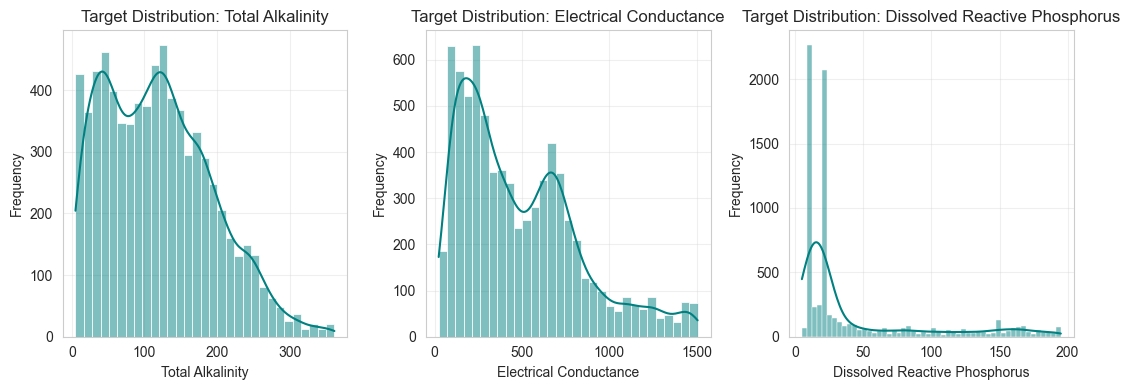

In [13]:
# Separate features by type for programmatic plotting
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = [c for c in num_cols if c not in TARGET_COL]
cat_cols = [c for c in cat_cols if c not in TARGET_COL]

n_targets = len(TARGET_COL)
cols_per_row = 3
n_rows = (n_targets + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
axes = np.array(axes).reshape(-1)  # handle 1-row/1-col safely

for idx, t_col in enumerate(TARGET_COL):
    sns.histplot(df[t_col].dropna(), kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f"Target Distribution: {t_col}")
    axes[idx].set_xlabel(t_col)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_targets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Numeric Feature Distribution

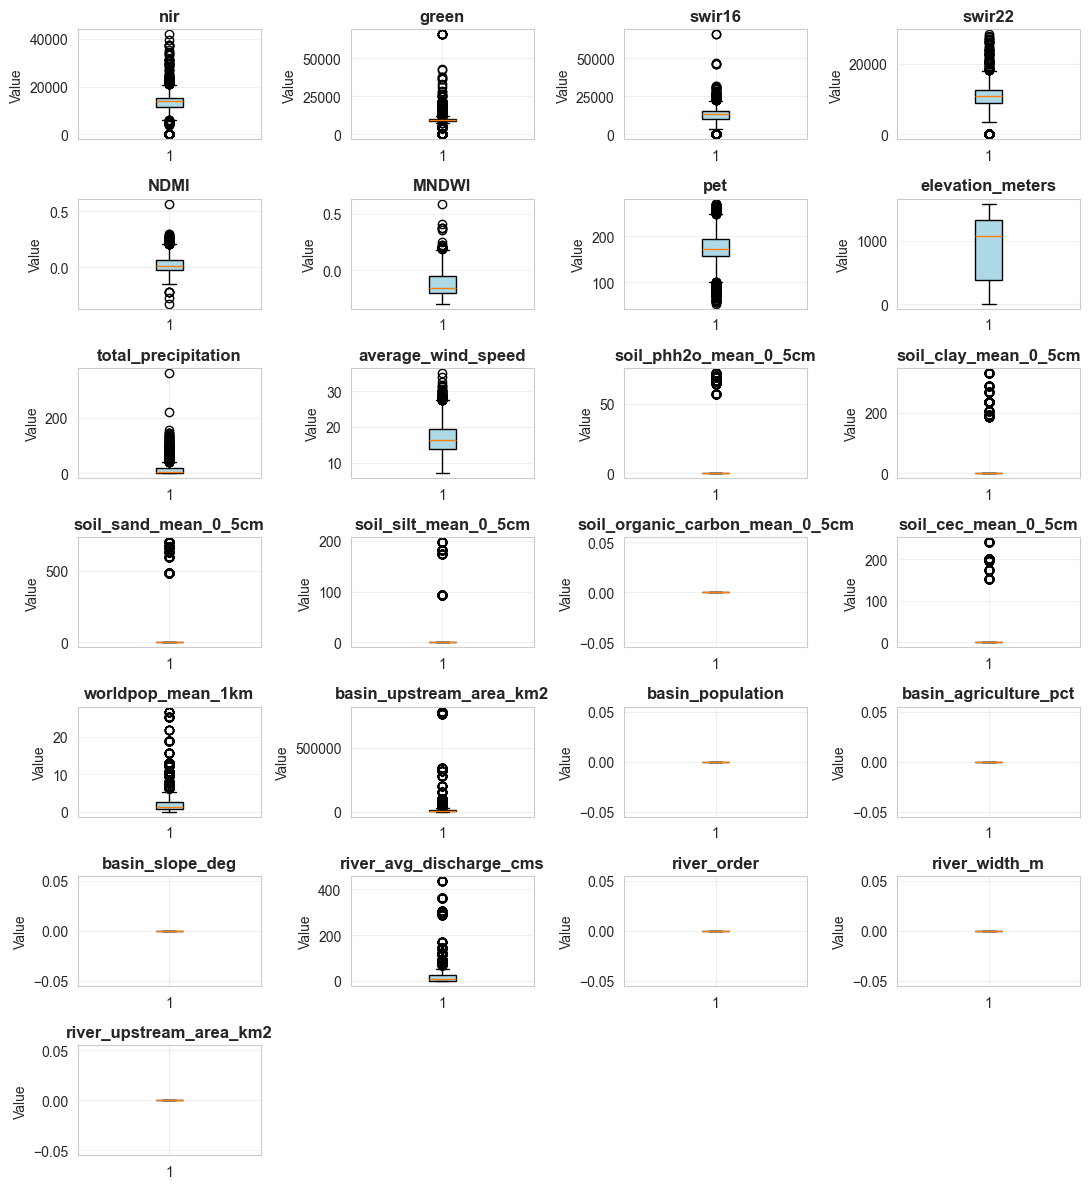

In [14]:
if num_cols:
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
    axes = axes.flatten() # Safe because cols_per_row > 1
    
    for idx, col in enumerate(num_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()

,Feature,Skewness,Kurtosis
17,basin_upstream_area_km2,7.207,56.350
13,soil_silt_mean_0_5cm,6.826,46.916
15,soil_cec_mean_0_5cm,5.542,29.426
21,river_avg_discharge_cms,4.335,22.605
11,soil_clay_mean_0_5cm,4.256,16.785
12,soil_sand_mean_0_5cm,3.966,13.942
10,soil_phh2o_mean_0_5cm,3.853,12.905
8,total_precipitation,3.397,26.578
1,green,3.151,53.044
16,worldpop_mean_1km,2.731,8.966


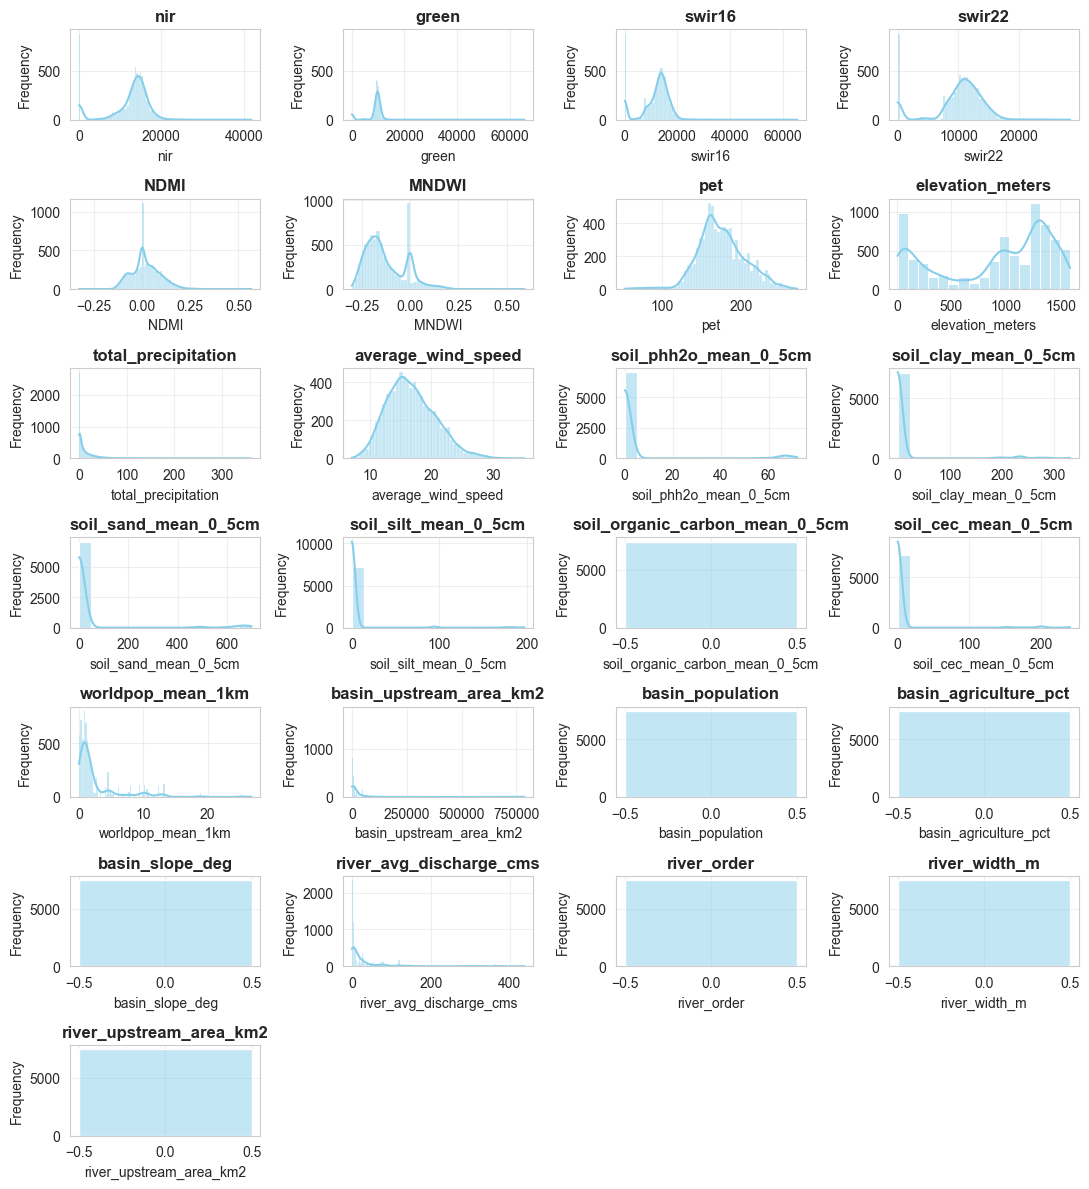

In [15]:
# Skewness and Kurtosis for numeric features
if num_cols:
    dist_stats = []
    for col in num_cols:
        dist_stats.append({
            'Feature': col,
            'Skewness': round(skew(df[col].dropna()), 3),
            'Kurtosis': round(kurtosis(df[col].dropna()), 3)
        })
    
    dist_df = pd.DataFrame(dist_stats)
    display(dist_df.sort_values(by='Skewness', key=abs, ascending=False))
    
    # Histogram + KDE plots for numeric features
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for distribution analysis.")

### Categorical Feature Distribution

In [15]:
# if cat_cols:
#     cols_per_row = 3
#     n_rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
    
#     fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
#     axes = axes.flatten()
    
#     MAX_CATEGORIES = 15 # Safety valve for high-cardinality columns
    
#     for idx, col in enumerate(cat_cols):
#         value_counts = df[col].value_counts()
        
#         # Apply safety valve
#         if len(value_counts) > MAX_CATEGORIES:
#             top_counts = value_counts.iloc[:MAX_CATEGORIES]
#             other_count = pd.Series({'...Others': value_counts.iloc[MAX_CATEGORIES:].sum()})
#             value_counts = pd.concat([top_counts, other_count])
            
#         axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#         axes[idx].set_xticks(range(len(value_counts)))
#         axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
#         axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
#         axes[idx].set_ylabel('Count')
#         axes[idx].grid(True, alpha=0.3)
    
#     # Hide empty subplots
#     for idx in range(len(cat_cols), len(axes)):
#         axes[idx].set_visible(False)
        
#     plt.tight_layout()
#     plt.show()

### Correlation Matrix

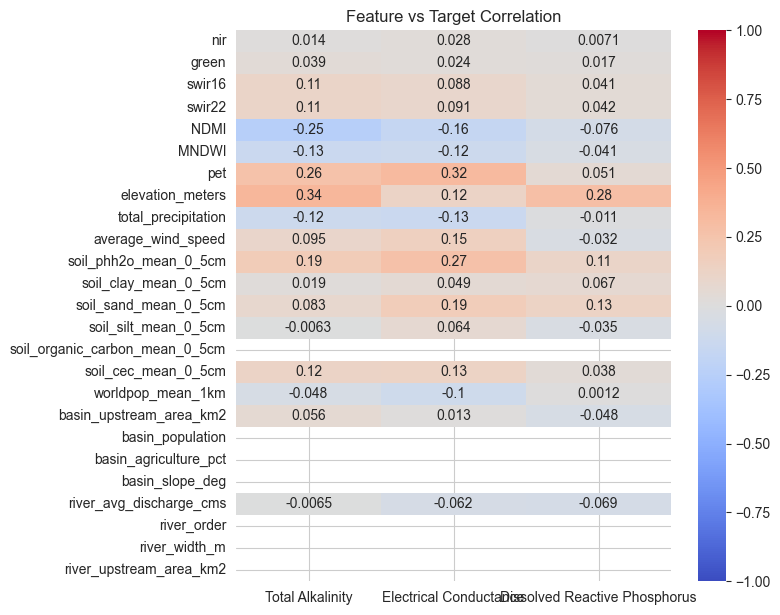

In [16]:
# Feature-to-target correlation only
feature_target_corr = df[num_cols + TARGET_COL].corr().loc[num_cols, TARGET_COL]

plt.figure(figsize=(8, max(6, len(num_cols) * 0.25)))
sns.heatmap(feature_target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Feature vs Target Correlation")
plt.tight_layout()
plt.show()

### Missing Data Patterns

In [17]:
# Missing value heatmap
missing_data = df.isnull()

if missing_data.any().any():
    plt.figure(figsize=(12, 6))
    sns.heatmap(missing_data, cbar=True, cmap='viridis', yticklabels=False)
    plt.title("Missing Data Heatmap (Yellow = Missing)")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()
    
    # Missing data correlation
    if missing_data.sum().sum() > 0:
        missing_corr = missing_data.corr().round(2)

        # Only show if there's meaningful correlation between missing values
        if (missing_corr.abs() > 0.5).sum().sum() > len(missing_corr):
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                missing_corr,
                annot=True,
                fmt=".2f",
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                center=0
            )
            plt.title("Missing Data Correlation (Do missing values occur together?)")
            plt.tight_layout()
            plt.show()
else:
    print("✓ No missing data detected in the training set.")

✓ No missing data detected in the training set.


### Target Relationship Analysis

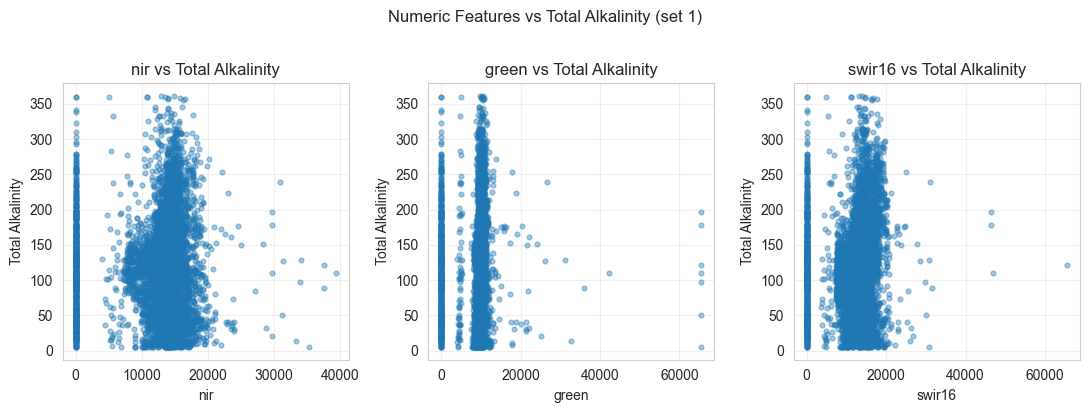

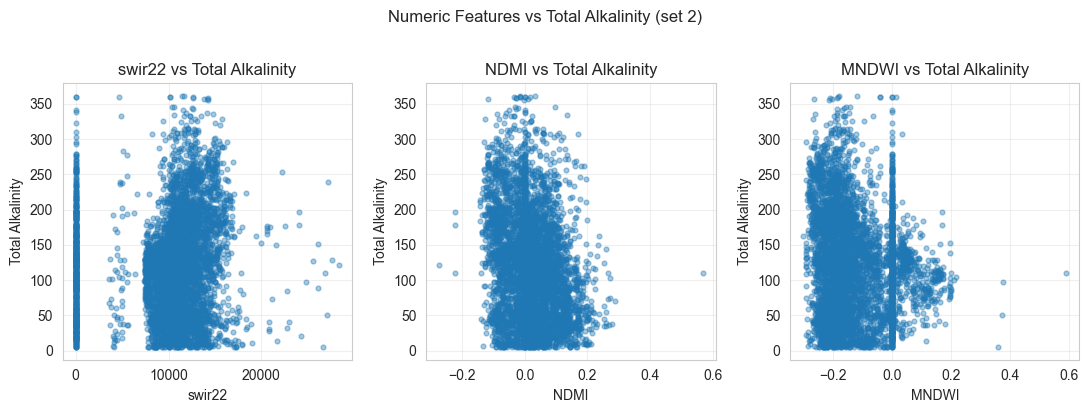

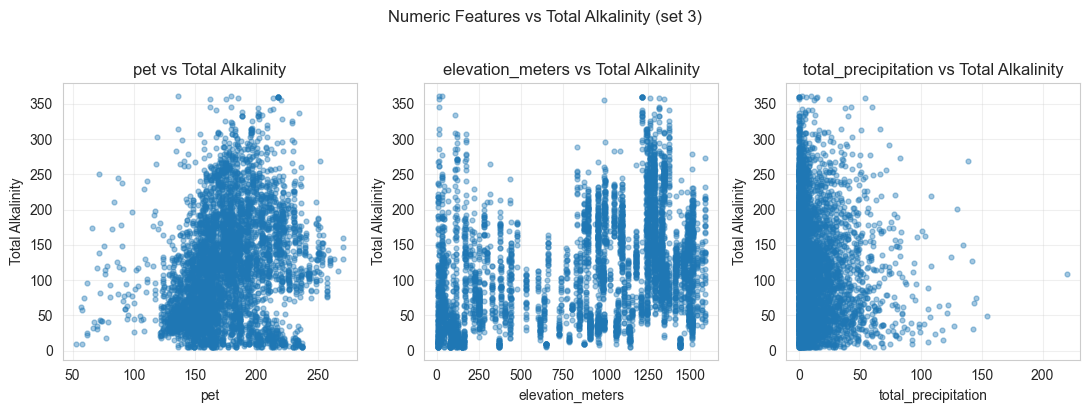

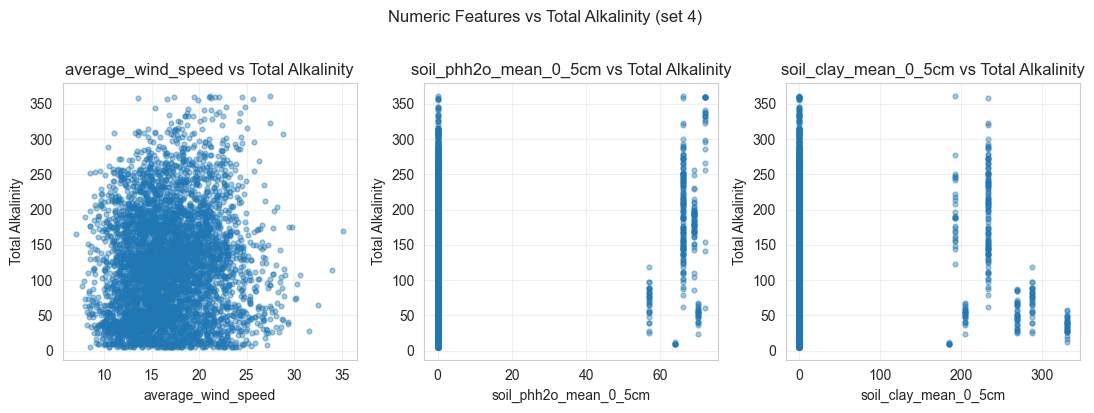

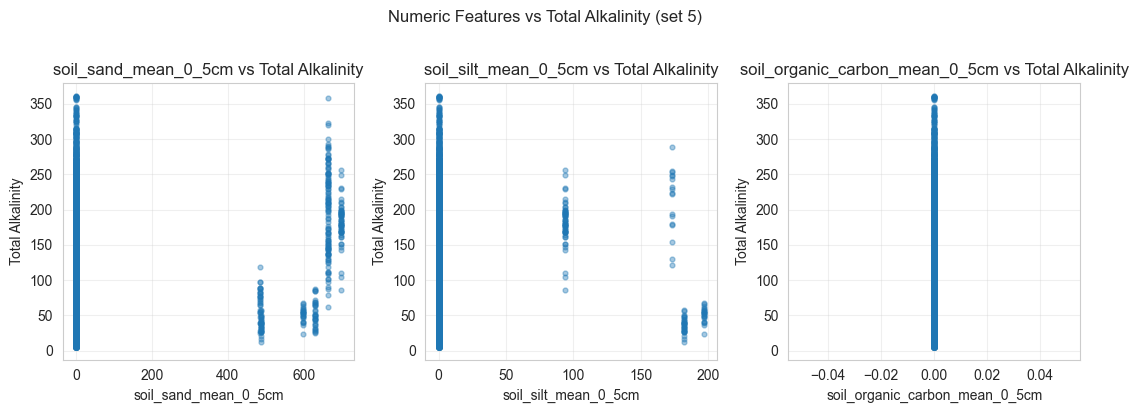

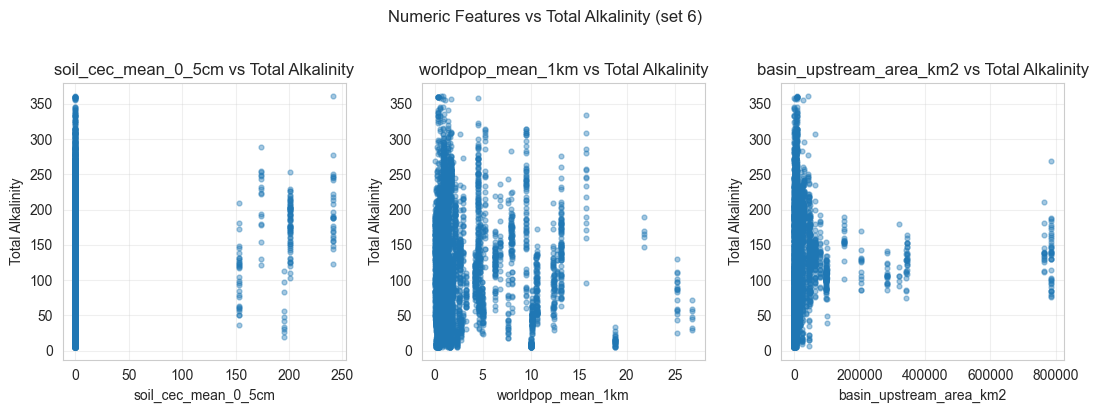

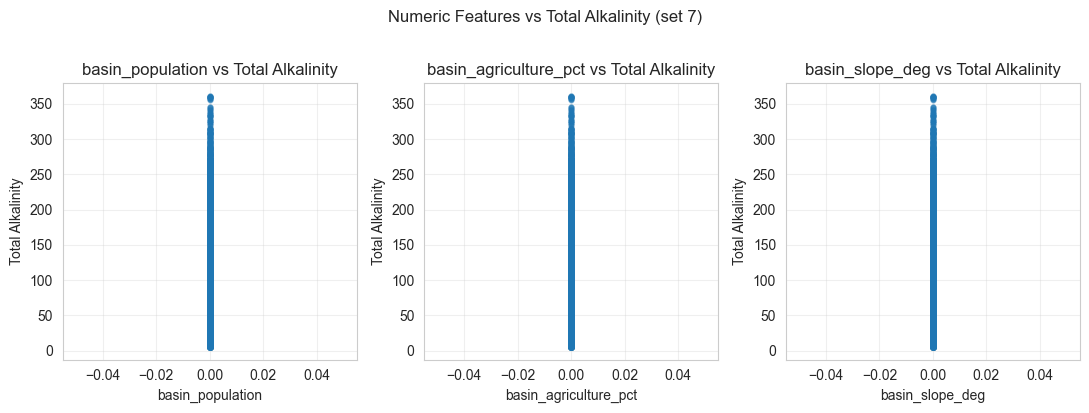

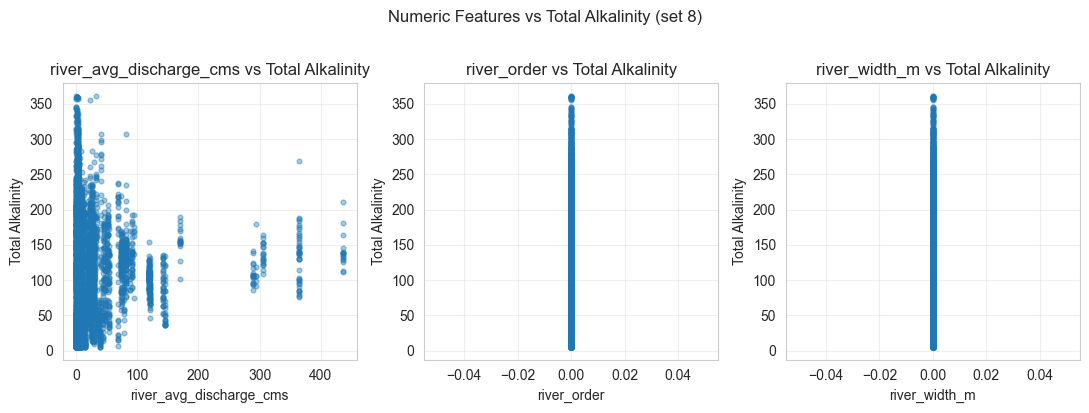

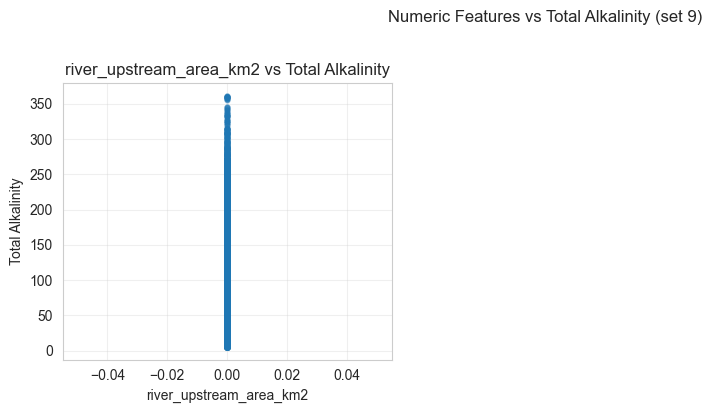

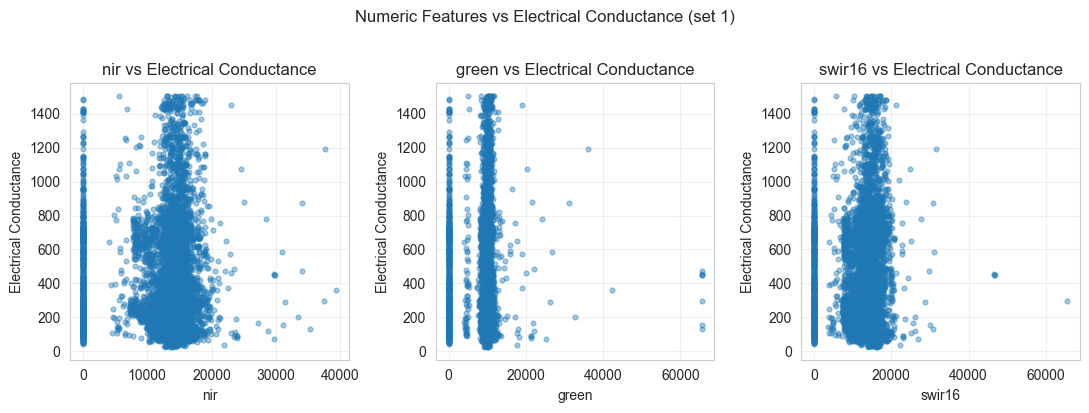

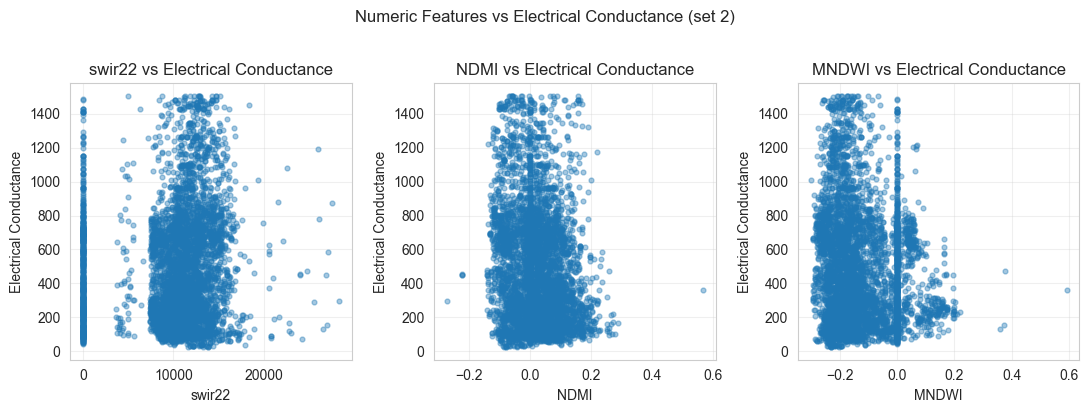

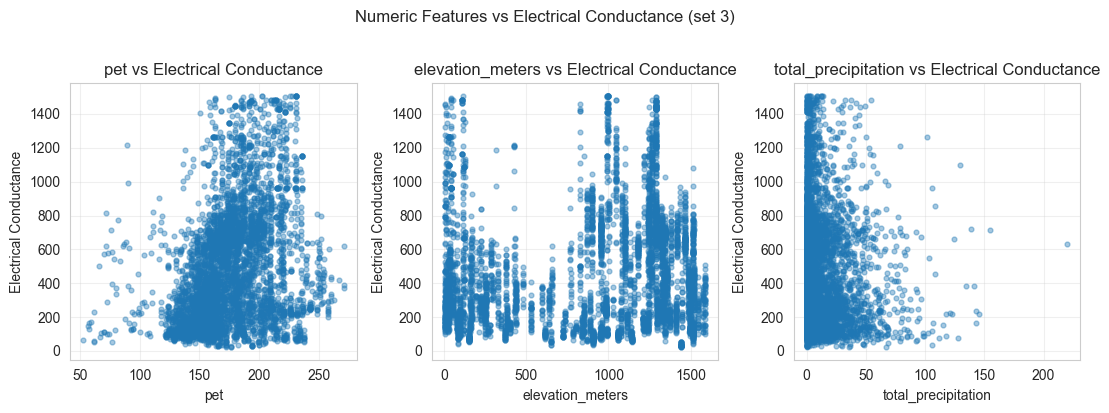

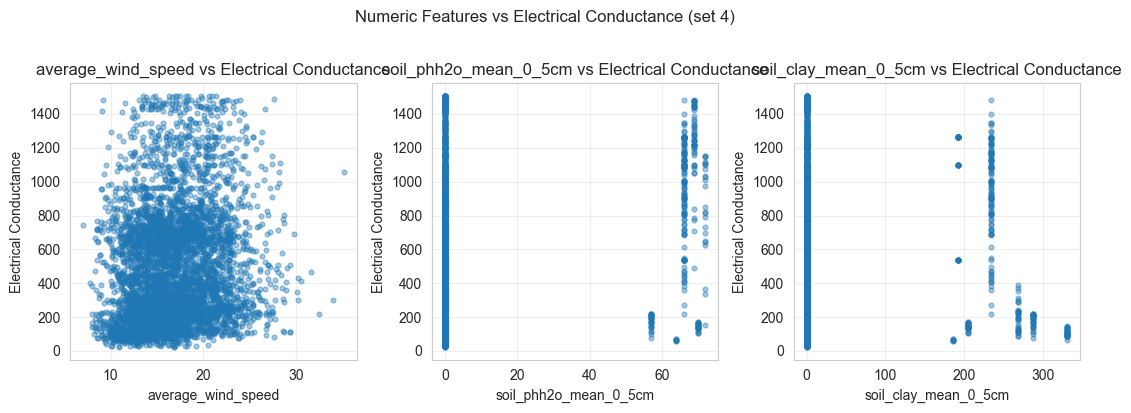

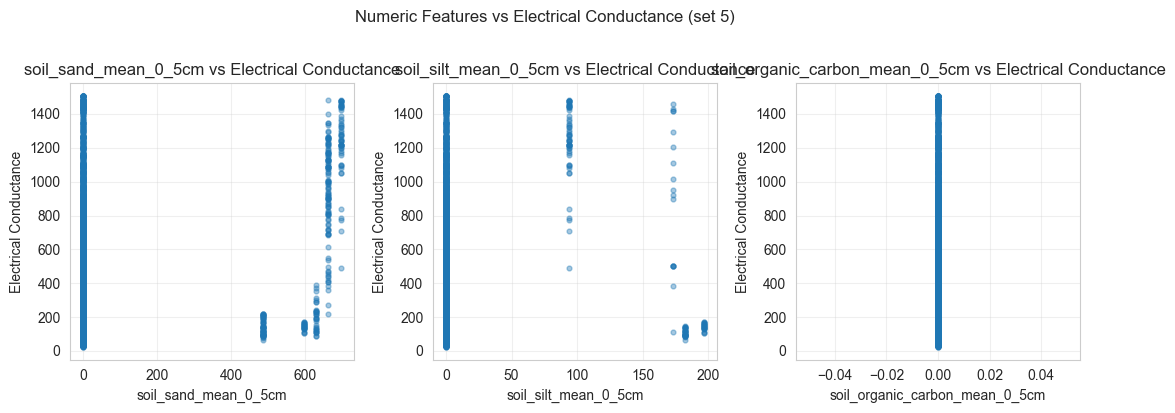

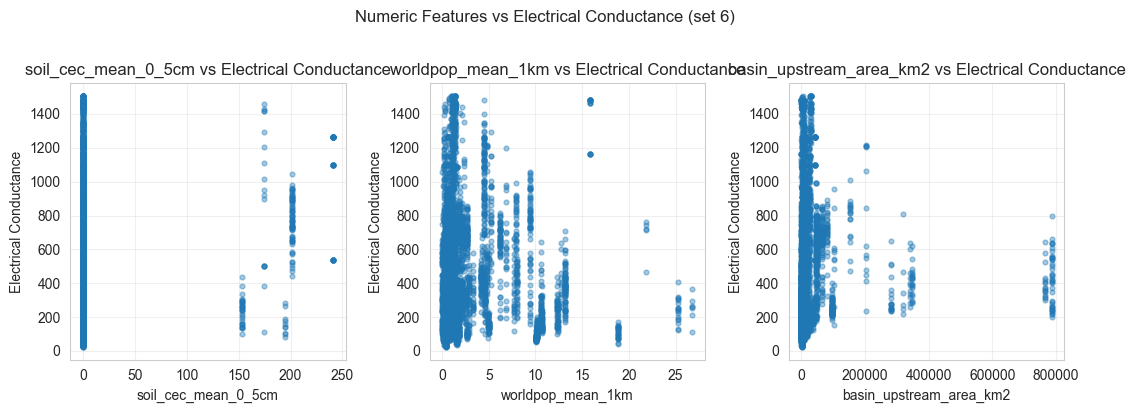

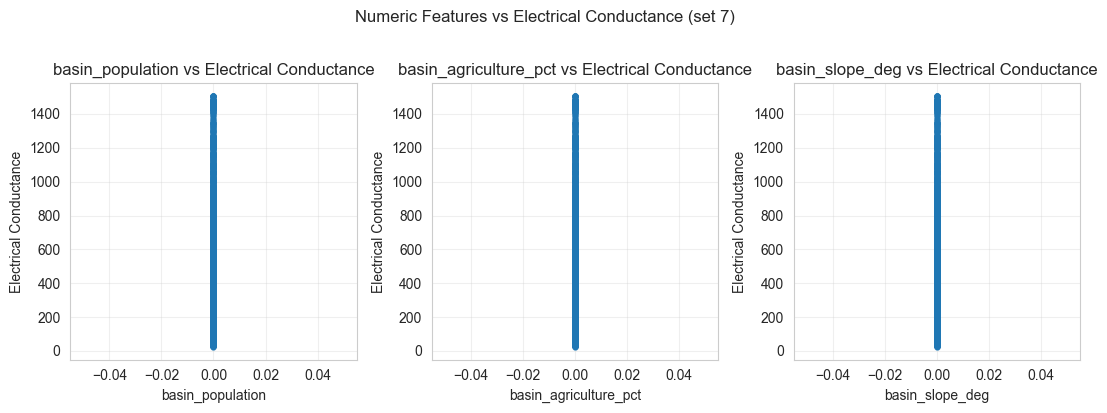

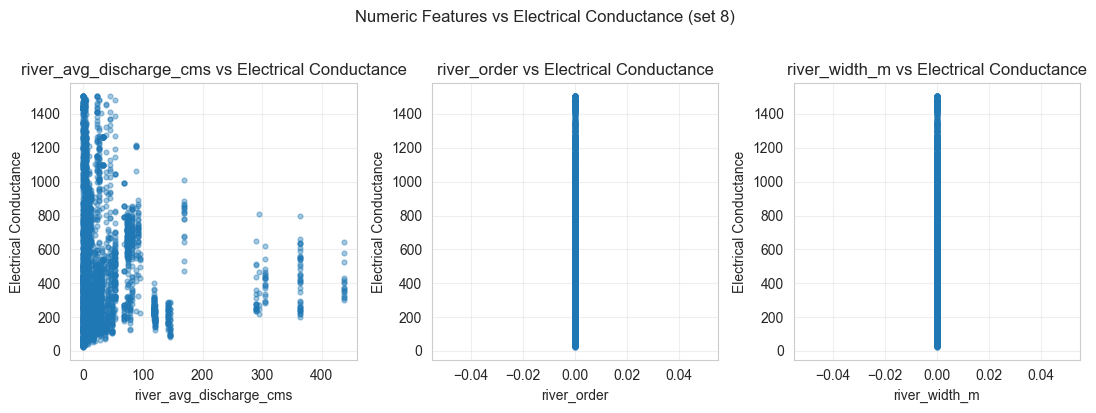

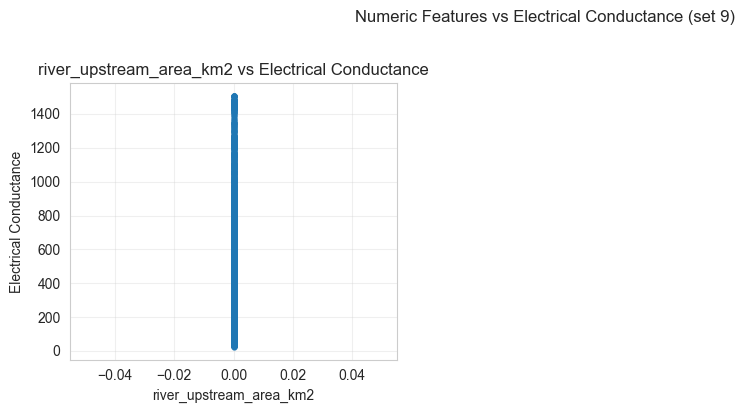

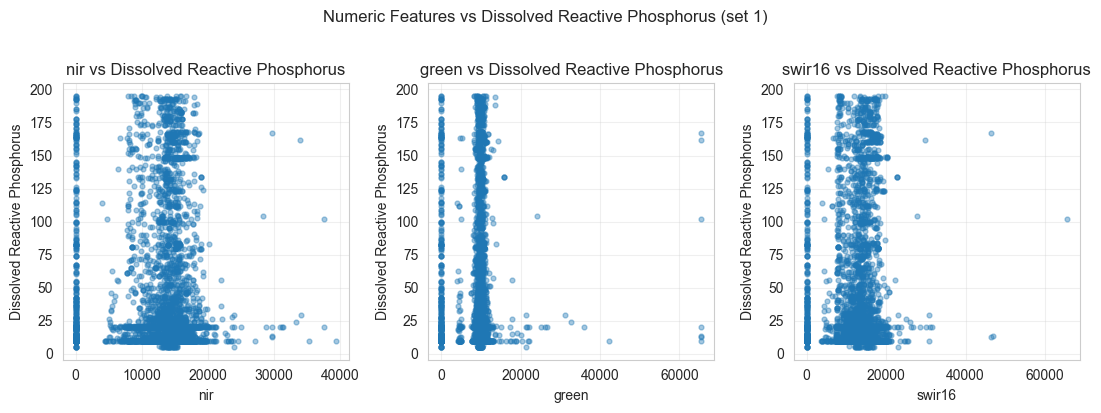

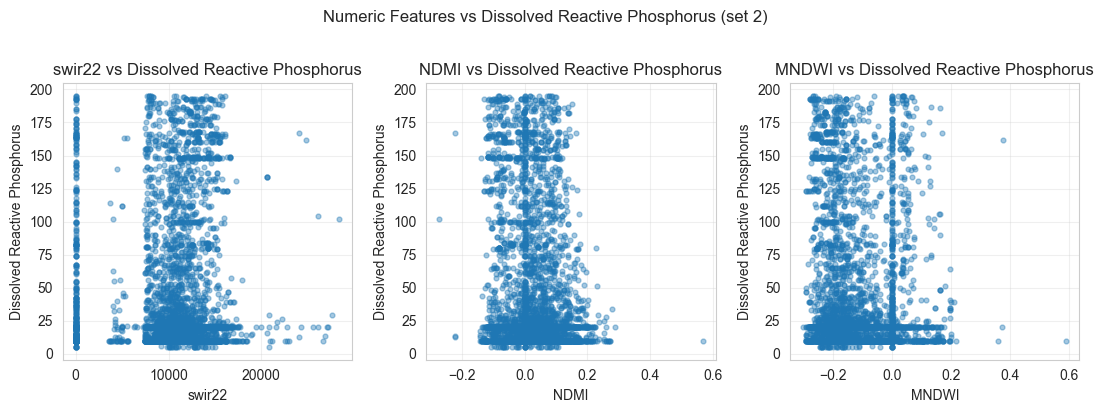

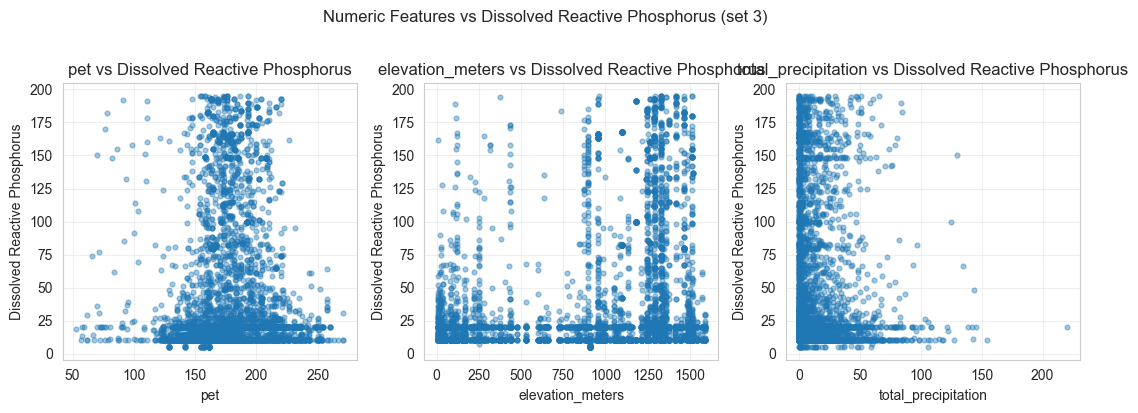

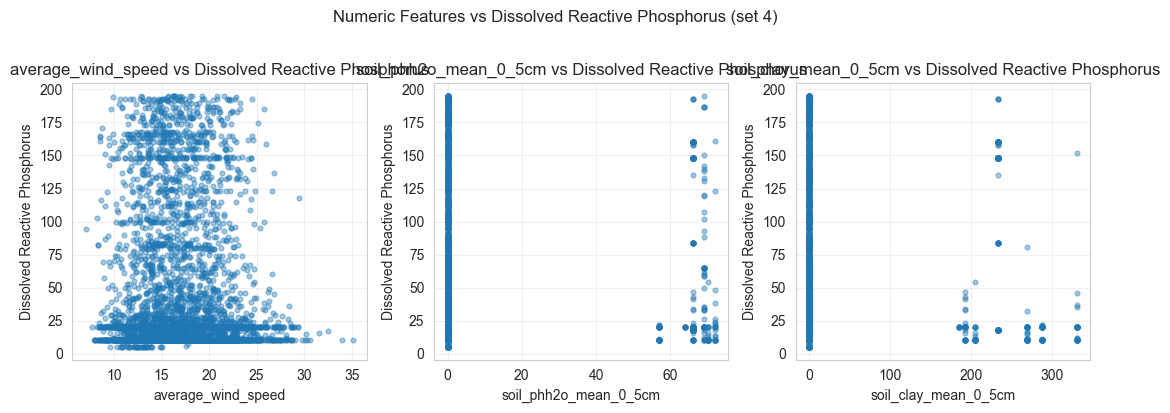

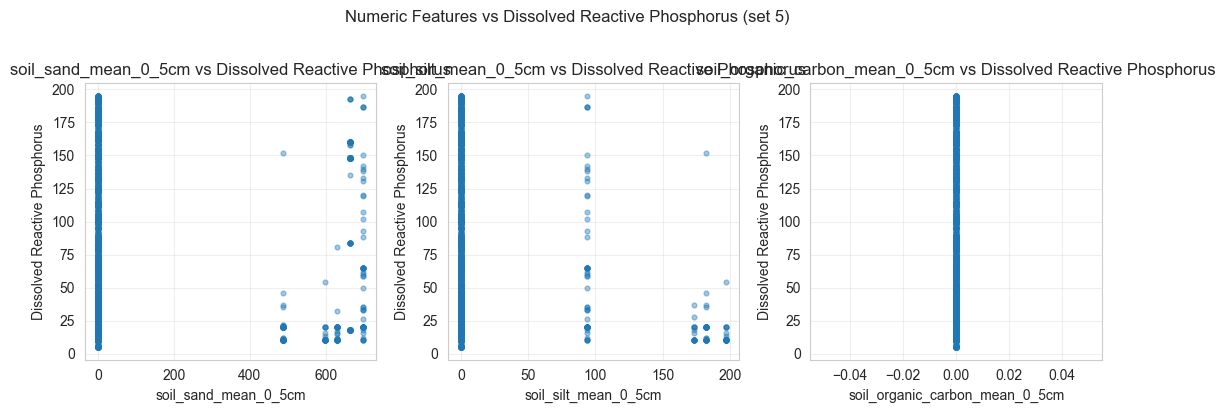

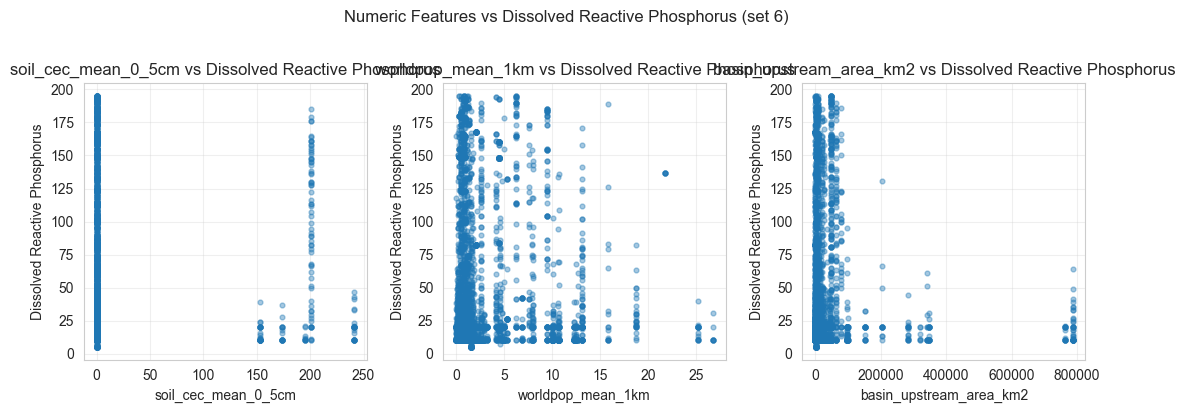

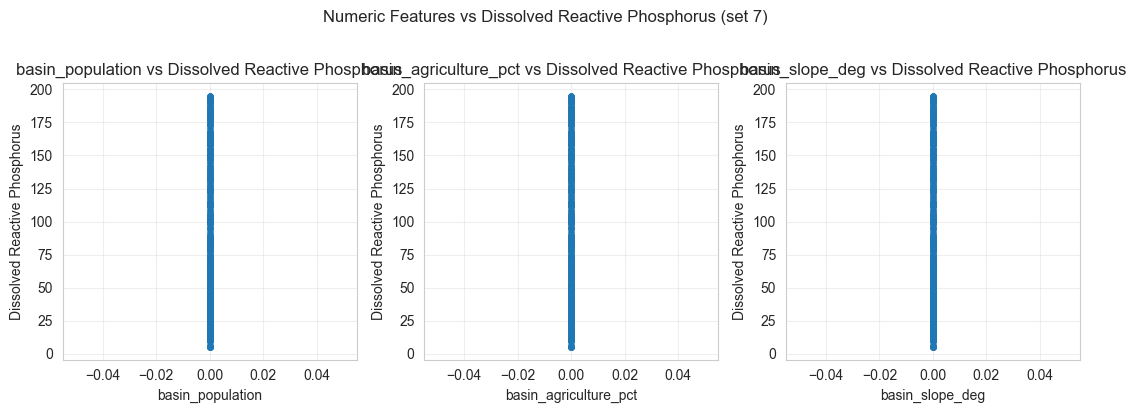

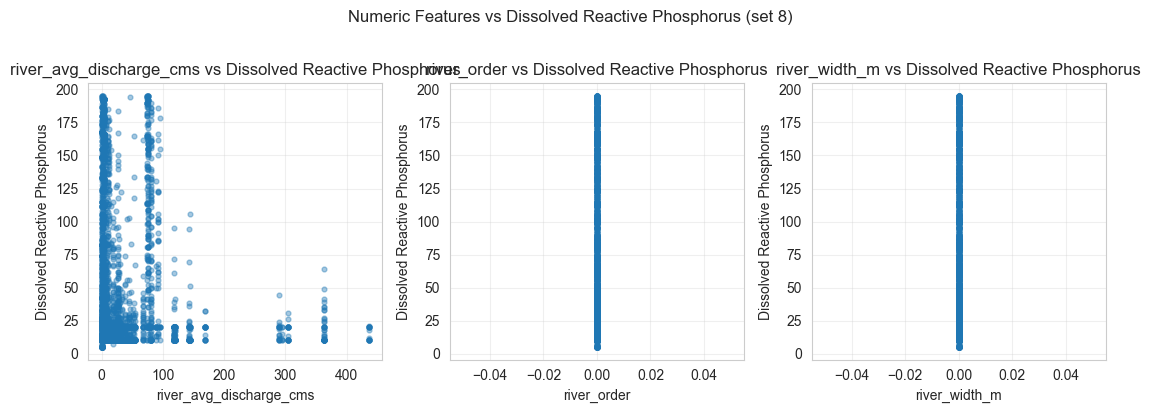

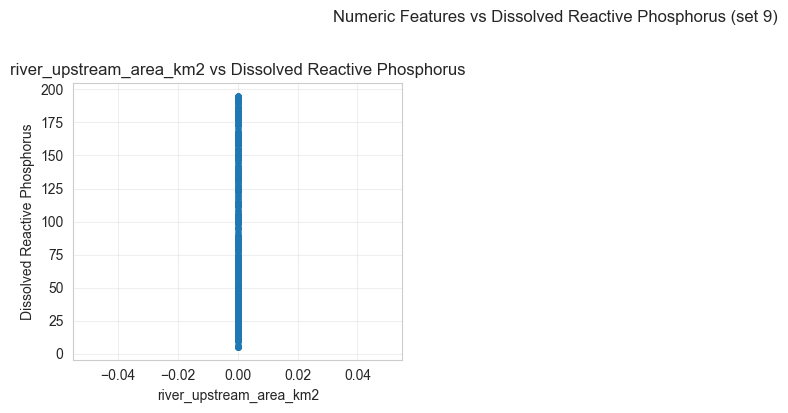

In [18]:
# Numeric Features vs Target
if num_cols and TARGET_COL:
    cols_per_row = 3
    plots_per_figure = 3

    for t_col in TARGET_COL:
        # chunk numeric columns so each target gets multiple small figures
        for start in range(0, len(num_cols), plots_per_figure):
            chunk_cols = num_cols[start:start + plots_per_figure]
            n_plots = len(chunk_cols)
            n_rows = (n_plots + cols_per_row - 1) // cols_per_row

            fig, axes = plt.subplots(
                n_rows,
                cols_per_row,
                figsize=safe_figsize(n_rows, width=11, row_height=2.4, max_height=10)
            )
            axes = np.array(axes).reshape(-1)

            for idx, col in enumerate(chunk_cols):
                ax = axes[idx]

                plot_df = df[[col, t_col]].dropna()
                if len(plot_df) > 5000:
                    plot_df = plot_df.sample(5000, random_state=42)

                ax.scatter(plot_df[col], plot_df[t_col], alpha=0.4, s=12)
                ax.set_xlabel(col)
                ax.set_ylabel(t_col)
                ax.set_title(f"{col} vs {t_col}")
                ax.grid(True, alpha=0.3)

            for idx in range(n_plots, len(axes)):
                axes[idx].set_visible(False)

            fig.suptitle(
                f"Numeric Features vs {t_col} "
                f"(set {start // plots_per_figure + 1})",
                y=1.02
            )
            plt.tight_layout()
            plt.show()
else:
    print("No numeric features or target columns available for regression relationship plots.")

### Outlier Detection (IQR Method)

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
1,green,1161,15.57,7518.00,11830.00
16,worldpop_mean_1km,1019,13.67,-2.35,5.54
0,nir,1005,13.48,6004.25,20866.25
17,basin_upstream_area_km2,1003,13.45,-19227.45,36472.15
21,river_avg_discharge_cms,990,13.28,-36.13,64.45
3,swir22,944,12.66,3459.50,18179.50
2,swir16,931,12.49,2945.00,22505.00
8,total_precipitation,529,7.10,-24.32,41.47
10,soil_phh2o_mean_0_5cm,423,5.67,0.00,0.00
12,soil_sand_mean_0_5cm,415,5.57,0.00,0.00


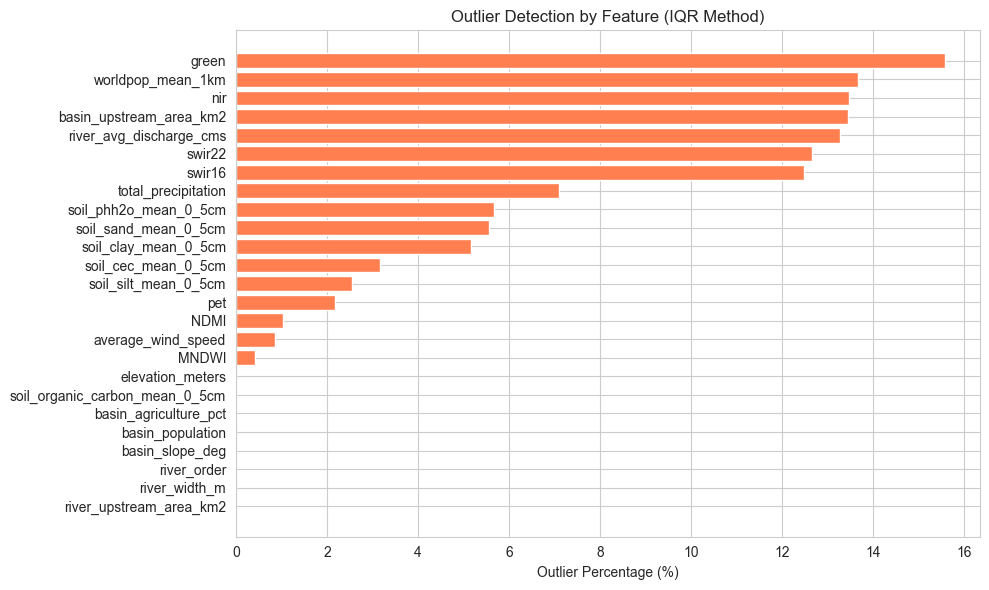

In [19]:
# Identify outliers using IQR method
if num_cols:
    outlier_summary = []
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Feature': col,
            'Outlier Count': outlier_count,
            'Outlier %': round(outlier_pct, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2)
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)
    display(outlier_df)
    
    # Visualize outlier percentage
    if outlier_df['Outlier %'].sum() > 0:
        plt.figure(figsize=(10, 6))
        plt.barh(outlier_df['Feature'], outlier_df['Outlier %'], color='coral')
        plt.xlabel('Outlier Percentage (%)')
        plt.title('Outlier Detection by Feature (IQR Method)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns to check for outliers.")

### Temporal Analysis (If Applicable)

In [20]:
# Temporal analysis for multi-target regression
DATE_COL = "Sample Date"

if DATE_COL in df.columns:
    # Safe datetime parse
    df_time = df.copy()
    df_time[DATE_COL] = pd.to_datetime(df_time[DATE_COL], errors="coerce", dayfirst=True)

    # Drop rows where date failed to parse
    df_time = df_time.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

    if len(df_time) == 0:
        print(f"No valid datetime values found in '{DATE_COL}'.")
    else:
        print(f"Using date column: {DATE_COL}")
        print(f"Date range: {df_time[DATE_COL].min().date()} to {df_time[DATE_COL].max().date()}")

        # 1) Raw scatter per target over time
        n_targets = len(TARGET_COL)
        fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, t_col in enumerate(TARGET_COL):
            plot_df = df_time[[DATE_COL, t_col]].dropna()
            axes[i].scatter(plot_df[DATE_COL], plot_df[t_col], alpha=0.35, s=12, label="raw")
            axes[i].set_title(f"{t_col} over time")
            axes[i].set_ylabel(t_col)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend(loc="upper right")

        axes[-1].set_xlabel(DATE_COL)
        plt.tight_layout()
        plt.show()

        # 2) Monthly trend per target (mean)
        monthly = (
            df_time.set_index(DATE_COL)[TARGET_COL]
            .resample("ME")
            .mean()
            .dropna(how="all")
        )

        if not monthly.empty:
            fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
            axes = np.array(axes).reshape(-1)

            for i, t_col in enumerate(TARGET_COL):
                axes[i].plot(monthly.index, monthly[t_col], marker="o", linewidth=2)
                axes[i].set_title(f"Monthly mean: {t_col}")
                axes[i].set_ylabel(t_col)
                axes[i].grid(True, alpha=0.3)

            axes[-1].set_xlabel(DATE_COL)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data to compute monthly trends.")
else:
    print("No temporal features detected. Set DATE_COL to your date column name.")

No temporal features detected. Set DATE_COL to your date column name.


### Cardinality Check

In [ ]:
# # Identify high-cardinality categorical features
# if cat_cols:
#     cardinality_info = []
    
#     for col in cat_cols:
#         unique_count = df[col].nunique()
#         cardinality_pct = (unique_count / len(df)) * 100
        
#         cardinality_info.append({
#             'Feature': col,
#             'Unique Values': unique_count,
#             'Cardinality %': round(cardinality_pct, 2),
#             'Type': 'High' if unique_count > 50 else ('Medium' if unique_count > 10 else 'Low')
#         })
    
#     cardinality_df = pd.DataFrame(cardinality_info).sort_values(by='Unique Values', ascending=False)
#     display(cardinality_df)
    
#     # Flag high-cardinality features that may need special encoding
#     high_card_features = cardinality_df[cardinality_df['Type'] == 'High']['Feature'].tolist()
#     if high_card_features:
#         print(f"\n⚠️ High-cardinality features detected: {high_card_features}")
#         print("   Consider: Target encoding, frequency encoding, or feature hashing.")
# else:
#     print("No categorical columns to check for cardinality.")

### Class Imbalance Analysis

In [ ]:
# # Check for class imbalance (for classification tasks)
# if df[TARGET_COL].dtype == 'object' or df[TARGET_COL].nunique() < 20:
#     value_counts = df[TARGET_COL].value_counts()
#     value_pcts = df[TARGET_COL].value_counts(normalize=True) * 100
    
#     imbalance_df = pd.DataFrame({
#         'Class': value_counts.index,
#         'Count': value_counts.values,
#         'Percentage': [f"{pct:.2f}%" for pct in value_pcts.values]
#     })
    
#     print("Class Distribution:")
#     display(imbalance_df)
    
#     # Calculate imbalance ratio
#     if len(value_counts) == 2:
#         imbalance_ratio = value_counts.max() / value_counts.min()
#         print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        
#         if imbalance_ratio > 3:
#             print("⚠️ Significant class imbalance detected!")
#             print("   Consider: SMOTE, class weights, or stratified sampling.")
    
#     # Visualization
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Count plot
#     axes[0].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#     axes[0].set_xticks(range(len(value_counts)))
#     axes[0].set_xticklabels(value_counts.index, rotation=45)
#     axes[0].set_title('Class Distribution (Count)')
#     axes[0].set_ylabel('Count')
#     axes[0].grid(True, alpha=0.3)
    
#     # Pie chart
#     axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
#     axes[1].set_title('Class Distribution (Percentage)')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Target variable is continuous (regression task). Class imbalance analysis not applicable.")

### Multicollinearity Check

In [21]:
# VIF (Variance Inflation Factor) Analysis
if len(num_cols) > 1:
    # Prepare data for VIF (drop NaNs)
    vif_data = df[num_cols].dropna()
    
    if len(vif_data) > 0 and vif_data.shape[1] > 1:
        vif_values = []
        
        for i, col in enumerate(vif_data.columns):
            try:
                vif = variance_inflation_factor(vif_data.values, i)
                vif_values.append({
                    'Feature': col,
                    'VIF': round(vif, 2)
                })
            except:
                vif_values.append({
                    'Feature': col,
                    'VIF': 'Error'
                })
        
        vif_df = pd.DataFrame(vif_values).sort_values(by='VIF', ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce'))
        display(vif_df)
        
        print("\n💡 VIF Interpretation:")
        print("   VIF < 5: Low multicollinearity")
        print("   VIF 5-10: Moderate multicollinearity")
        print("   VIF > 10: High multicollinearity (consider removing)")
    
    # High correlation pairs
    print("\n" + "="*50)
    print("High Correlation Pairs (|r| > 0.8):")
    print("="*50)
    
    corr_matrix = df[num_cols].corr()
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': round(corr_val, 3)
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', key=abs, ascending=False)
        display(high_corr_df)
        print("\n⚠️ Consider removing one feature from each highly correlated pair.")
    else:
        print("✓ No highly correlated feature pairs detected (|r| > 0.8).")
else:
    print("Not enough numeric columns for multicollinearity analysis.")

c:\Users\USER\miniconda3\envs\python10\lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
0,nir,823.18
2,swir16,717.23
3,swir22,303.88
1,green,138.86
5,MNDWI,47.49
4,NDMI,25.65
6,pet,23.04
9,average_wind_speed,16.75
21,river_avg_discharge_cms,6.15
12,soil_sand_mean_0_5cm,5.56



💡 VIF Interpretation:
   VIF < 5: Low multicollinearity
   VIF 5-10: Moderate multicollinearity
   VIF > 10: High multicollinearity (consider removing)

High Correlation Pairs (|r| > 0.8):


,Feature 1,Feature 2,Correlation
5,swir16,swir22,0.983
1,nir,swir16,0.914
2,nir,swir22,0.896
6,basin_upstream_area_km2,river_avg_discharge_cms,0.865
3,green,swir16,0.847
0,nir,green,0.840
4,green,swir22,0.837



⚠️ Consider removing one feature from each highly correlated pair.


### Geography Visualization

Latitude range: -34.4058 to -22.2256
Longitude range: 17.7303 to 32.3250
Date range: 2011-01-03 to 2015-12-31
Total sample points: 7455


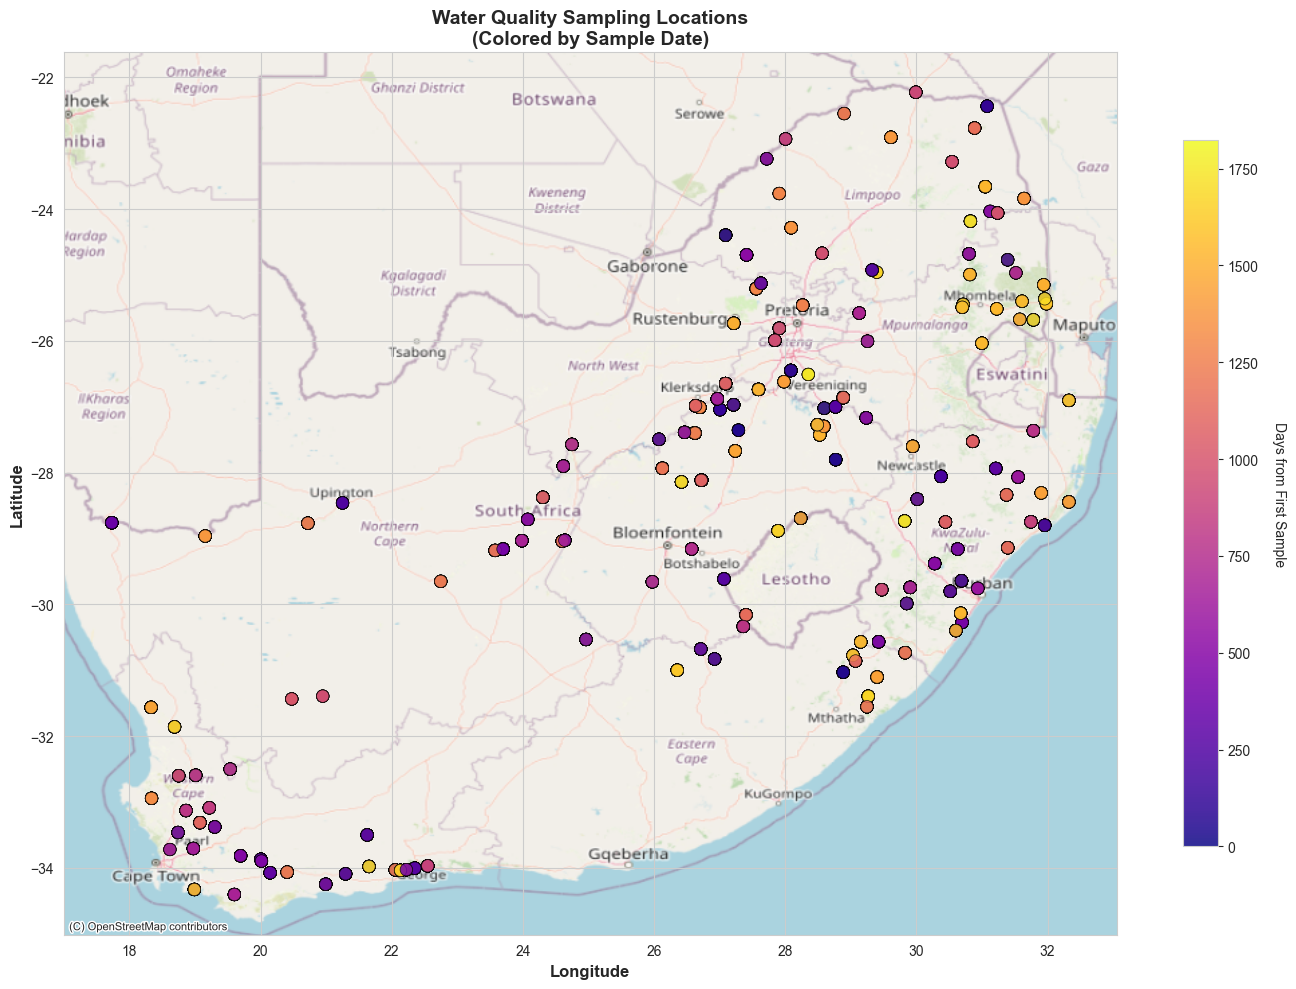

In [22]:
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    
    df_geo = df[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_geo = df_geo.dropna()
    
    df_geo['Sample Date'] = pd.to_datetime(df_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_geo = df_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_geo['Sample Date'] - df_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_geo['Latitude'].min(), df_geo['Latitude'].max()
    lon_min, lon_max = df_geo['Longitude'].min(), df_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_geo['Longitude'], 
        df_geo['Latitude'], 
        c=date_numeric, 
        cmap='plasma', 
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles (must come after setting xlim/ylim)
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Water Quality Sampling Locations\n(Colored by Sample Date)', fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_geo['Sample Date'].min().date()} to {df_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_geo)}")
    
    plt.tight_layout()
    plt.show()

### Inspecting Validation File

In [22]:
VALIDATION_DATA_PATH = '../data/interim/master_test.parquet'
df_validation = pd.read_parquet(VALIDATION_DATA_PATH)

print(f"Validation data shape: {df_validation.shape}")
print("\n" + "="*70)
print("VALIDATION SET - BIRD'S EYE VIEW")
print("="*70 + "\n")

# Peek at the data (chunked columns)
chunk_size = 8

df_val_display = df_validation.copy()
num_val_cols = df_val_display.select_dtypes(include=[np.number]).columns
df_val_display[num_val_cols] = df_val_display[num_val_cols].round(4)

for i in range(0, df_val_display.shape[1], chunk_size):
    cols = df_val_display.columns[i:i + chunk_size]
    print(f"Preview columns {i+1} to {i + len(cols)}:")
    display(df_val_display[cols].head())

# Data types and missing values
print("Data types and missing values:")
val_info_df = pd.DataFrame({
    "Data Type": df_val_display.dtypes.astype(str),
    "Missing Values": df_val_display.isnull().sum(),
    "Missing %": (df_val_display.isnull().sum() / len(df_val_display) * 100).round(2),
    "Unique Values": df_val_display.nunique()
}).sort_values(by="Missing %", ascending=False)

display(val_info_df)

# Statistical summary in chunks
cols_1 = df_val_display.columns[0:6]
print("Describe columns 1 to 6:")
desc_1 = df_val_display[cols_1].describe(include="all").T
num_cols_1 = desc_1.select_dtypes(include="number").columns
display(desc_1.style.format({c: "{:.4f}" for c in num_cols_1}))

if df_val_display.shape[1] > 6:
    cols_2 = df_val_display.columns[6:12]
    print("Describe columns 7 to 12:")
    display(df_val_display[cols_2].describe(include="all").T.round(4))

if df_val_display.shape[1] > 12:
    cols_3 = df_val_display.columns[12:18]
    print("Describe columns 13 to 18:")
    display(df_val_display[cols_3].describe(include="all").T.round(4))


Validation data shape: (200, 31)

VALIDATION SET - BIRD'S EYE VIEW

Preview columns 1 to 8:


,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,NDMI
0,0.0,0.0,0.0,15229.0,12868.0,14797.0,12421.0,0.0144
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
2,0.0,0.0,0.0,16221.0,9304.5,12536.5,9958.0,0.1281
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
4,0.0,0.0,0.0,9125.0,11100.5,9455.0,8711.0,-0.0178


Preview columns 9 to 16:


,MNDWI,pet,elevation_meters,total_precipitation,average_wind_speed,soil_phh2o_mean_0_5cm,soil_clay_mean_0_5cm,soil_sand_mean_0_5cm
0,-0.0697,161.9,781.0,17.6,16.3250,66.0,249.0,517.0
1,0.0000,177.6,261.0,3.8,19.5500,65.0,222.0,583.0
2,-0.1480,158.4,154.0,2.0,16.2750,60.0,234.0,478.0
3,0.0000,130.0,17.0,9.2,23.5125,55.0,172.0,569.0
4,0.0801,152.5,349.0,20.1,19.1250,62.0,252.0,404.0


Preview columns 17 to 24:


...

,count,mean,std,min,25%,50%,75%,max
Total Alkalinity,200.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Electrical Conductance,200.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Dissolved Reactive Phosphorus,200.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
nir,200.0000,13088.9750,4777.8756,0.0000,12634.2500,14271.2500,15599.0000,21308.0000
green,200.0000,8695.4700,3002.2073,0.0000,8717.2500,9413.0000,10091.8750,13553.0000
swir16,200.0000,11160.4700,4107.7784,0.0000,10607.3750,12104.5000,13180.5000,18512.5000


Describe columns 7 to 12:


,count,mean,std,min,25%,50%,75%,max
swir22,200.0,9318.8650,3432.7099,0.0000,8945.5000,9827.7500,10986.8750,16452.0000
NDMI,200.0,0.0719,0.0723,-0.1246,0.0068,0.0715,0.1297,0.2338
MNDWI,200.0,-0.1086,0.0733,-0.2372,-0.1531,-0.1245,-0.0905,0.1397
pet,200.0,160.2780,25.3465,60.5000,140.7500,158.4000,173.7000,218.2000
elevation_meters,200.0,382.1350,334.9407,6.0000,145.0000,196.0000,781.0000,966.0000
total_precipitation,200.0,13.9805,16.8324,0.0000,1.9000,7.9000,20.2750,93.9000


Describe columns 13 to 18:


,count,mean,std,min,25%,50%,75%,max
average_wind_speed,200.0,20.0894,4.6767,9.15,17.3188,19.1,22.1688,36.475
soil_phh2o_mean_0_5cm,200.0,64.6400,5.2458,55.00,60.0000,64.0,70.0000,76.000
soil_clay_mean_0_5cm,200.0,233.6900,24.1181,156.00,223.0000,234.0,249.0000,281.000
soil_sand_mean_0_5cm,200.0,513.0350,56.1059,404.00,478.0000,526.0,553.0000,658.000
soil_silt_mean_0_5cm,200.0,252.9500,44.7393,168.00,221.0000,234.0,287.0000,345.000
soil_organic_carbon_mean_0_5cm,200.0,0.0000,0.0000,0.00,0.0000,0.0,0.0000,0.000



VALIDATION SET - GEOGRAPHY VISUALIZATION

Latitude range: -34.0964 to -31.9031
Longitude range: 24.1964 to 28.5817
Date range: 2011-01-14 to 2015-12-28
Total sample points: 200


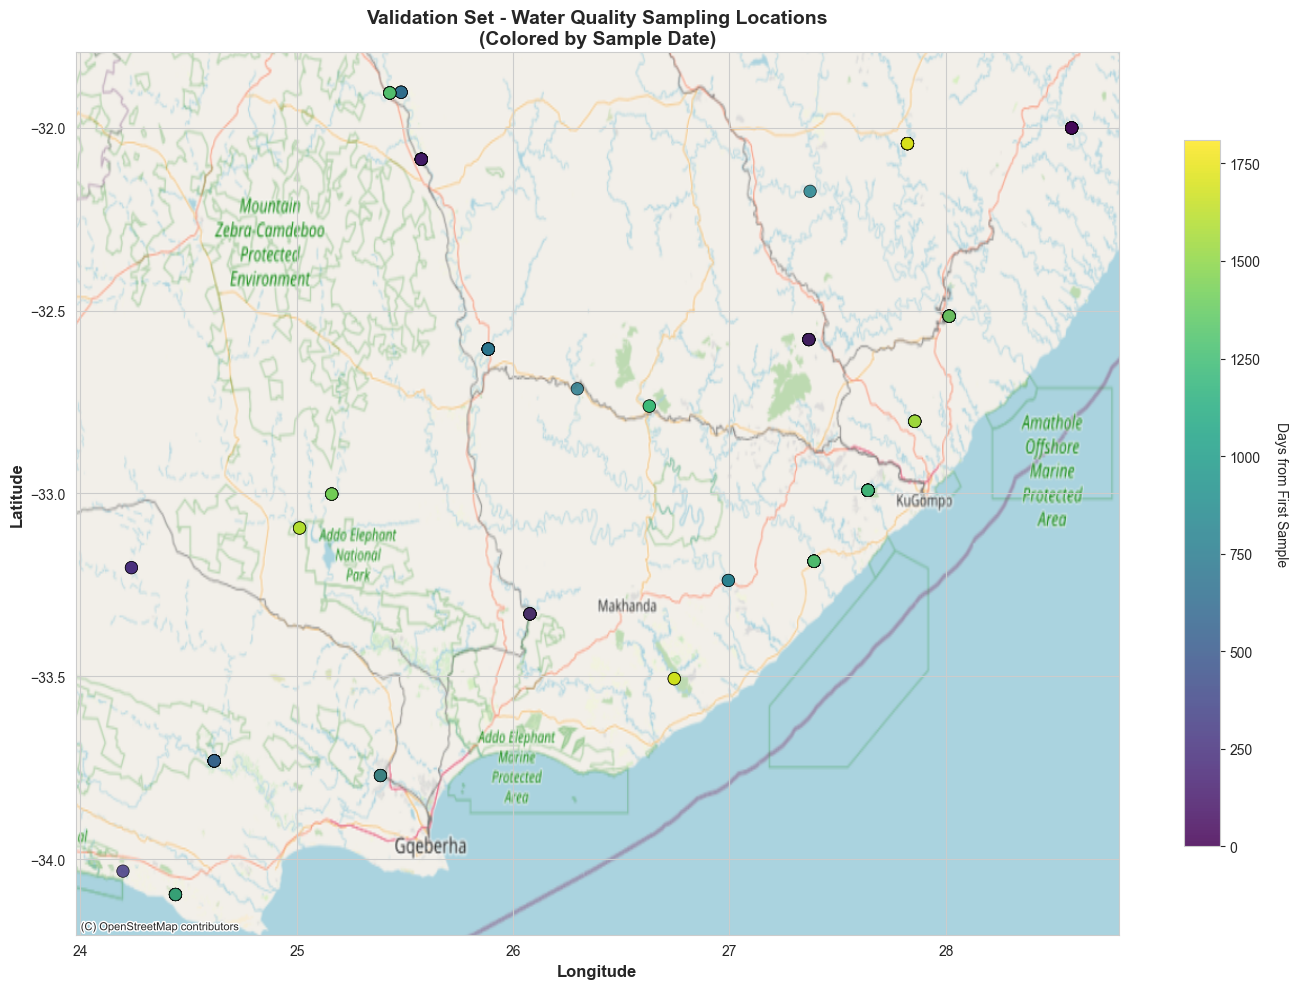

In [5]:
# Geography Visualization
print("\n" + "="*70)
print("VALIDATION SET - GEOGRAPHY VISUALIZATION")
print("="*70 + "\n")

if 'Latitude' in df_validation.columns and 'Longitude' in df_validation.columns:
    
    df_val_geo = df_validation[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_val_geo = df_val_geo.dropna()
    
    df_val_geo['Sample Date'] = pd.to_datetime(df_val_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_val_geo = df_val_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_val_geo['Sample Date'] - df_val_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_val_geo['Latitude'].min(), df_val_geo['Latitude'].max()
    lon_min, lon_max = df_val_geo['Longitude'].min(), df_val_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_val_geo['Longitude'], 
        df_val_geo['Latitude'], 
        c=date_numeric, 
        cmap='viridis',  # Different color scheme to distinguish from training
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Validation Set - Water Quality Sampling Locations\n(Colored by Sample Date)', 
                 fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_val_geo['Sample Date'].min().date()} to {df_val_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_val_geo)}")
    
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude columns not found in validation set.")

### Train vs Valid Data


TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)



,dataset,rows,lat_min,lat_max,lat_mean,lon_min,lon_max,lon_mean,date_min,date_max
0,train,7455,-34.405833,-22.225556,-28.483813,17.730278,32.325000,26.872603,2011-01-03,2015-12-31
1,valid,200,-34.096389,-31.903056,-32.816731,24.196389,28.581667,26.583118,2011-01-14,2015-12-28


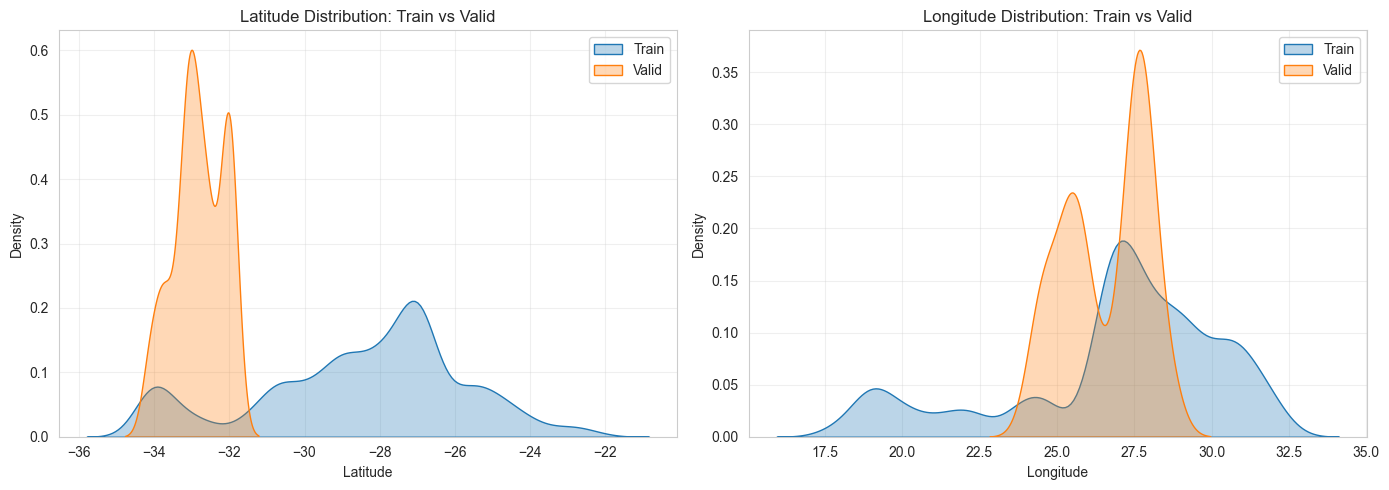

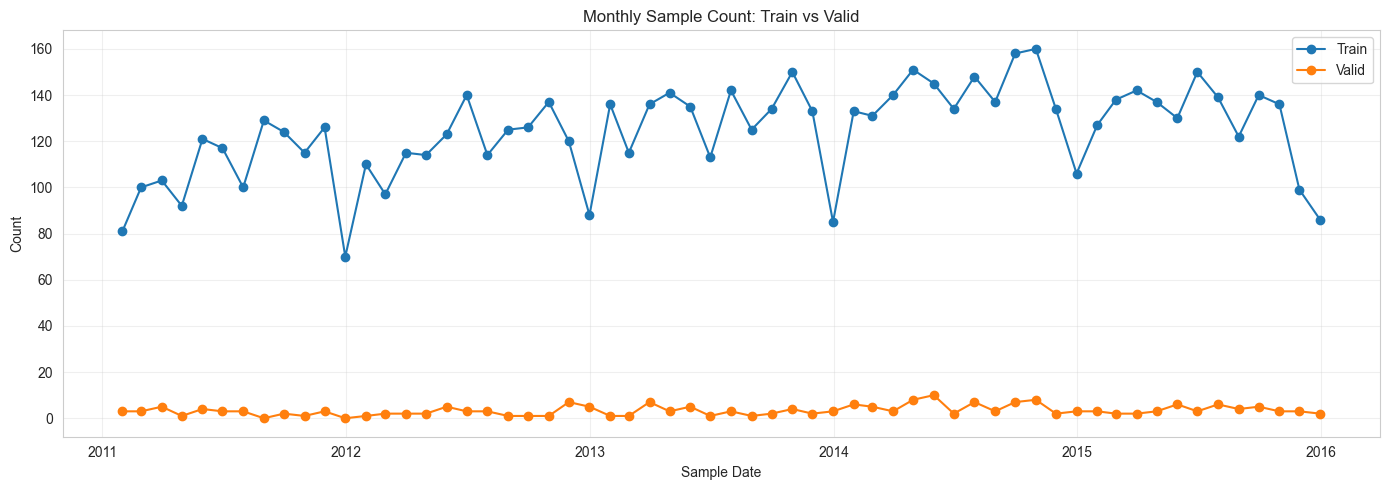

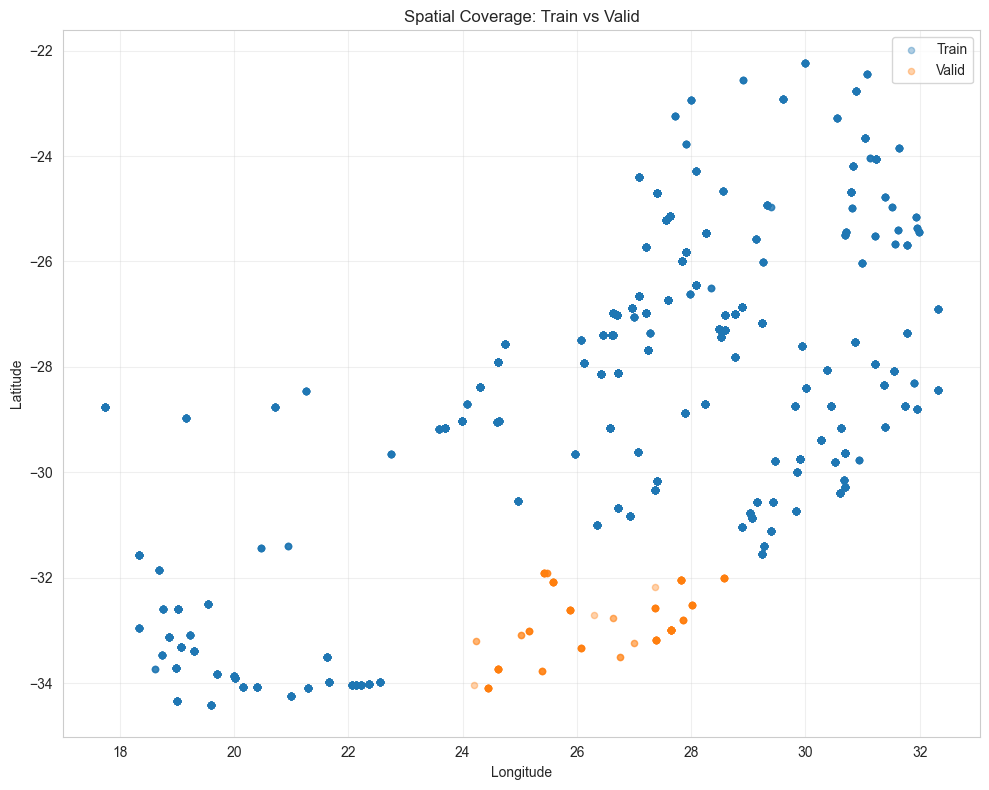

In [5]:
print("\n" + "=" * 70)
print("TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)")
print("=" * 70 + "\n")

DATE_COL = "Sample Date"
LAT_COL = "Latitude"
LON_COL = "Longitude"

# Build comparable subsets
train_cmp = df[[LAT_COL, LON_COL, DATE_COL]].copy()
valid_cmp = df_validation[[LAT_COL, LON_COL, DATE_COL]].copy()

for _df in (train_cmp, valid_cmp):
    _df[DATE_COL] = pd.to_datetime(_df[DATE_COL], errors="coerce", dayfirst=True)

train_cmp = train_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])
valid_cmp = valid_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])

# Summary table
summary = pd.DataFrame({
    "dataset": ["train", "valid"],
    "rows": [len(train_cmp), len(valid_cmp)],
    "lat_min": [train_cmp[LAT_COL].min(), valid_cmp[LAT_COL].min()],
    "lat_max": [train_cmp[LAT_COL].max(), valid_cmp[LAT_COL].max()],
    "lat_mean": [train_cmp[LAT_COL].mean(), valid_cmp[LAT_COL].mean()],
    "lon_min": [train_cmp[LON_COL].min(), valid_cmp[LON_COL].min()],
    "lon_max": [train_cmp[LON_COL].max(), valid_cmp[LON_COL].max()],
    "lon_mean": [train_cmp[LON_COL].mean(), valid_cmp[LON_COL].mean()],
    "date_min": [train_cmp[DATE_COL].min().date(), valid_cmp[DATE_COL].min().date()],
    "date_max": [train_cmp[DATE_COL].max().date(), valid_cmp[DATE_COL].max().date()],
})
display(summary)

# 1) Latitude/Longitude distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(train_cmp[LAT_COL], fill=True, alpha=0.30, label="Train", ax=axes[0], color="tab:blue")
sns.kdeplot(valid_cmp[LAT_COL], fill=True, alpha=0.30, label="Valid", ax=axes[0], color="tab:orange")
axes[0].set_title("Latitude Distribution: Train vs Valid")
axes[0].set_xlabel("Latitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.kdeplot(train_cmp[LON_COL], fill=True, alpha=0.30, label="Train", ax=axes[1], color="tab:blue")
sns.kdeplot(valid_cmp[LON_COL], fill=True, alpha=0.30, label="Valid", ax=axes[1], color="tab:orange")
axes[1].set_title("Longitude Distribution: Train vs Valid")
axes[1].set_xlabel("Longitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Sample date trend comparison (monthly count)
train_month = train_cmp.set_index(DATE_COL).resample("ME").size()
valid_month = valid_cmp.set_index(DATE_COL).resample("ME").size()

plt.figure(figsize=(14, 5))
plt.plot(train_month.index, train_month.values, marker="o", label="Train", color="tab:blue")
plt.plot(valid_month.index, valid_month.values, marker="o", label="Valid", color="tab:orange")
plt.title("Monthly Sample Count: Train vs Valid")
plt.xlabel("Sample Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Spatial overlay
plt.figure(figsize=(10, 8))
plt.scatter(train_cmp[LON_COL], train_cmp[LAT_COL], s=20, alpha=0.35, label="Train", color="tab:blue")
plt.scatter(valid_cmp[LON_COL], valid_cmp[LAT_COL], s=20, alpha=0.35, label="Valid", color="tab:orange")
plt.title("Spatial Coverage: Train vs Valid")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### LOSO Comparison

LOSO REGION DISTRIBUTION


,Train Count,Train %,Valid Count,Valid %
Region,,,,
Northern_Bulk,4661,62.5,0.0,0.0
Western_Cape,979,13.1,0.0,0.0
Eastern_Cape,1500,20.1,200.0,100.0


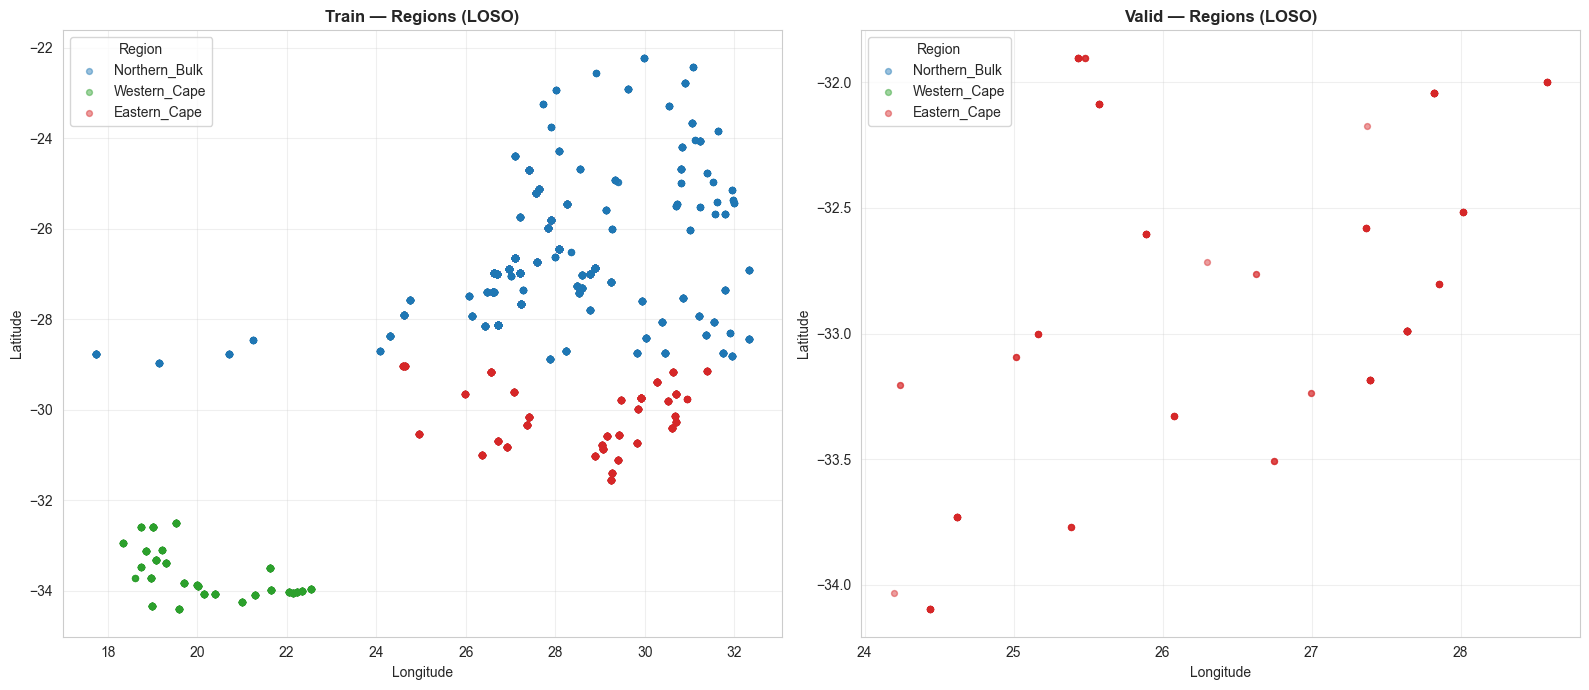

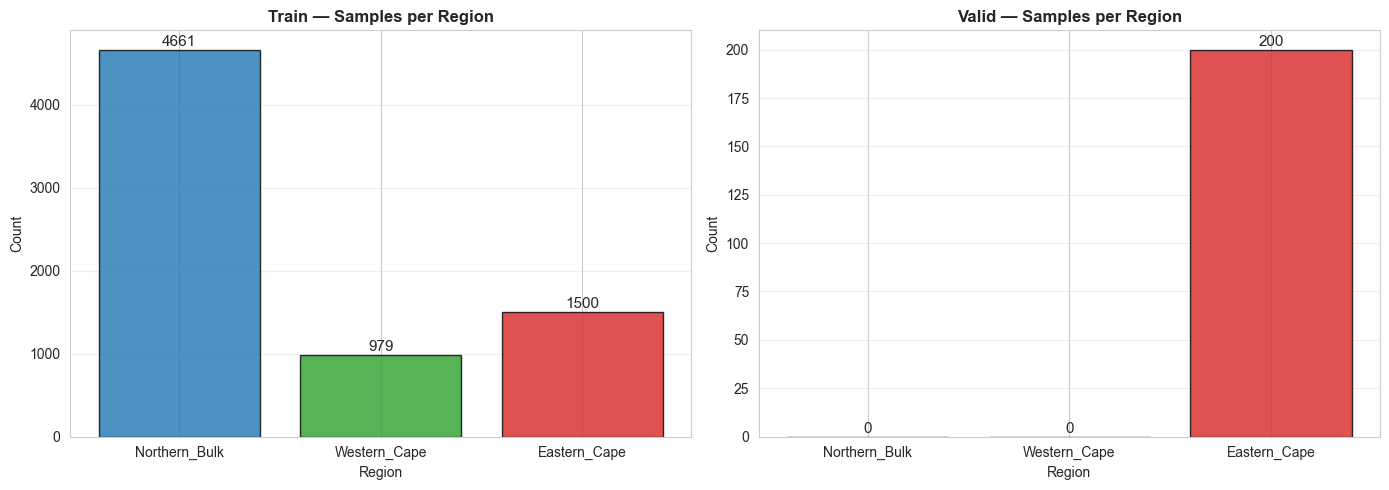

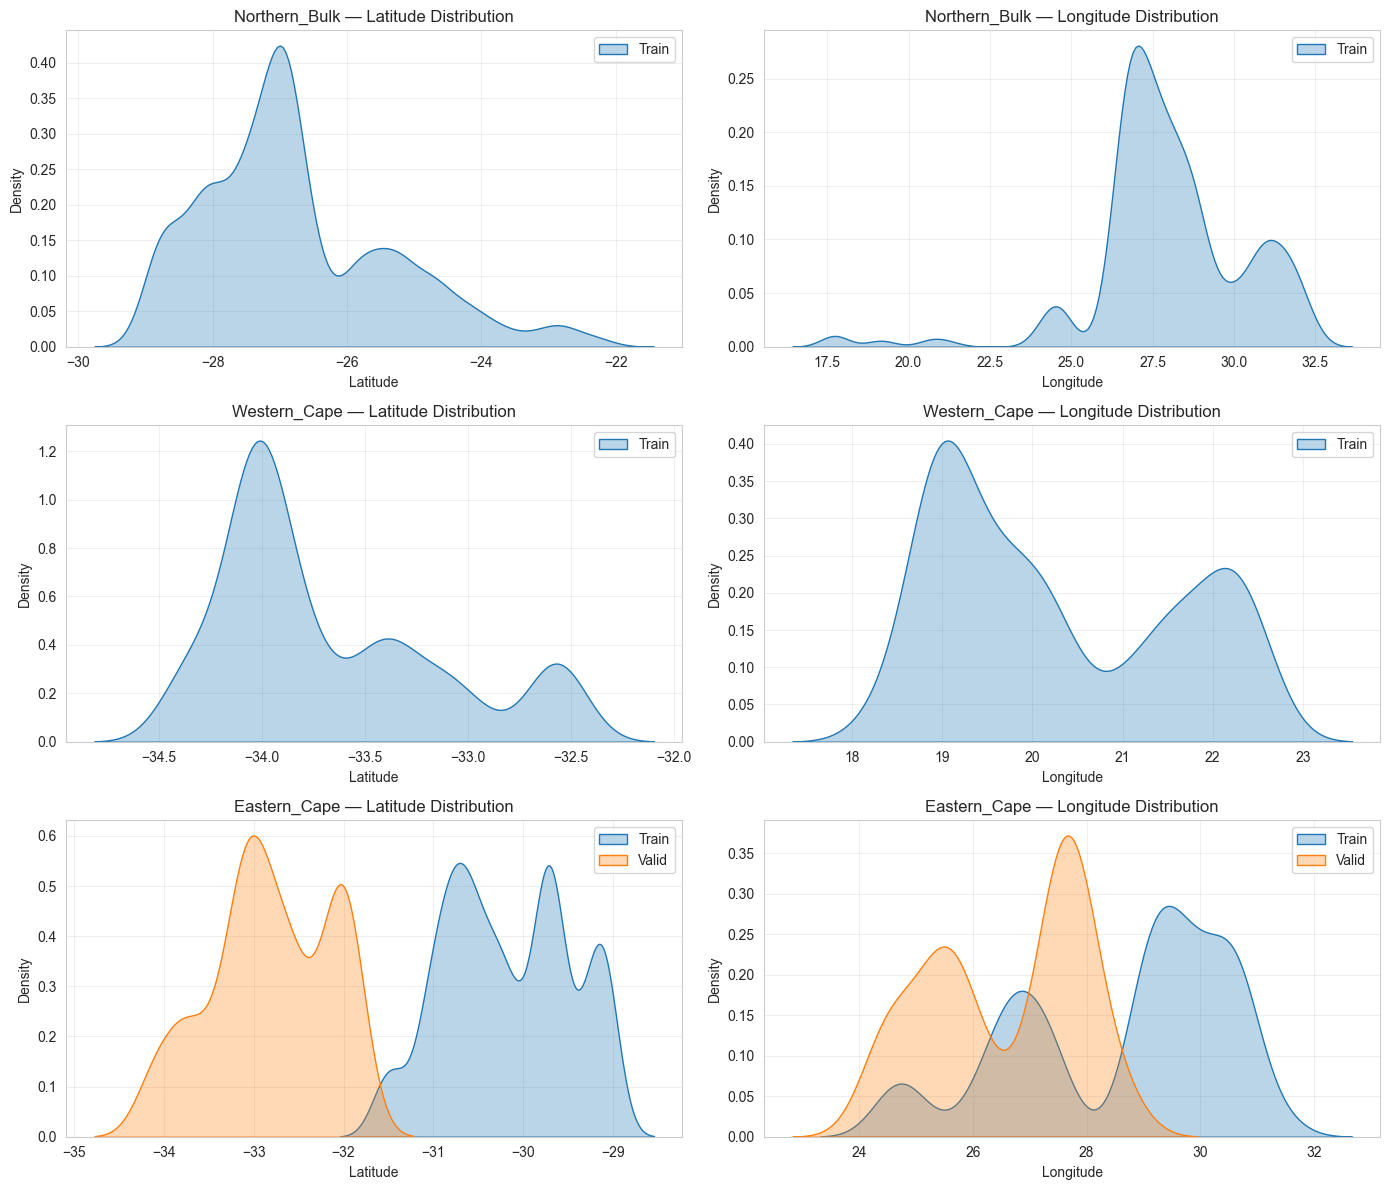

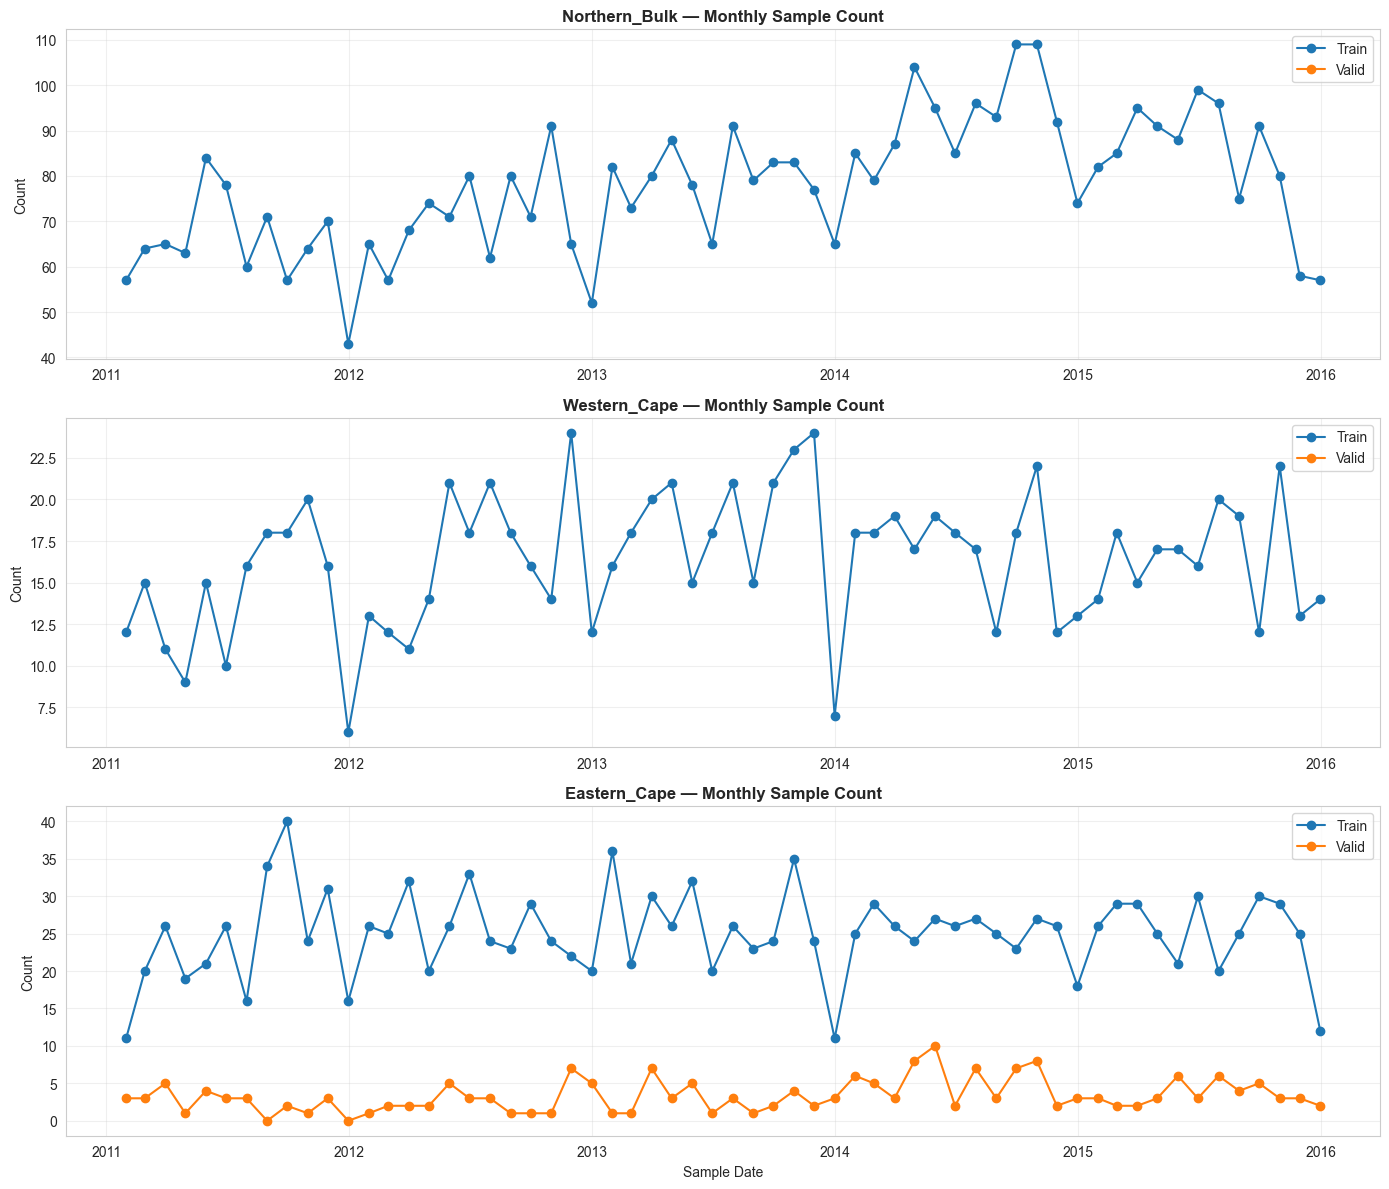


KS-TEST: DISTRIBUTION DRIFT (Train vs Valid per Region)


,Region,Feature,KS Stat,p-value,Drift?
0,Eastern_Cape,Latitude,1.0000,0.0,⚠️ Yes
1,Eastern_Cape,Longitude,0.6433,0.0,⚠️ Yes


In [6]:
def assign_region(row):
    lat, lon = row['Latitude'], row['Longitude']
    
    # True Cape Fold Belt / Mediterranean zone
    if lat <= -32.0 and lon < 24.0:
        return 'Western_Cape'
    
    # Highveld / Limpopo plateau
    elif lat >= -29.0:
        return 'Northern_Bulk'
    
    # Eastern Cape / Karoo transitional (your hardest zone)
    elif lat < -29.0 and lon >= 24.0:
        return 'Eastern_Cape'
    
    # Karoo interior buffer — currently being split ambiguously
    else:
        return 'Karoo_Buffer'  # Consider adding a 4th region

DATE_COL = "Sample Date"
LAT_COL = "Latitude"
LON_COL = "Longitude"

# ── Assign regions ────────────────────────────────────────────────────────────
train_loso = df[[LAT_COL, LON_COL, DATE_COL]].copy()
valid_loso = df_validation[[LAT_COL, LON_COL, DATE_COL]].copy()

for _df in (train_loso, valid_loso):
    _df[DATE_COL] = pd.to_datetime(_df[DATE_COL], errors="coerce", dayfirst=True)

train_loso = train_loso.dropna(subset=[LAT_COL, LON_COL, DATE_COL])
valid_loso = valid_loso.dropna(subset=[LAT_COL, LON_COL, DATE_COL])

train_loso["Region"] = train_loso.apply(assign_region, axis=1)
valid_loso["Region"] = valid_loso.apply(assign_region, axis=1)

REGIONS = ["Northern_Bulk", "Western_Cape", "Eastern_Cape"]
COLORS   = {"Northern_Bulk": "tab:blue", "Western_Cape": "tab:green", "Eastern_Cape": "tab:red"}

# ── 1) Region count summary ───────────────────────────────────────────────────
print("=" * 70)
print("LOSO REGION DISTRIBUTION")
print("=" * 70)

region_summary = pd.DataFrame({
    "Train Count":  train_loso["Region"].value_counts(),
    "Train %":      (train_loso["Region"].value_counts(normalize=True) * 100).round(1),
    "Valid Count":  valid_loso["Region"].value_counts(),
    "Valid %":      (valid_loso["Region"].value_counts(normalize=True) * 100).round(1),
}).loc[REGIONS].fillna(0)

display(region_summary)

# ── 2) Spatial scatter coloured by region ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (loso_df, title) in zip(axes, [
    (train_loso, "Train — Regions (LOSO)"),
    (valid_loso, "Valid — Regions (LOSO)"),
]):
    for region in REGIONS:
        subset = loso_df[loso_df["Region"] == region]
        ax.scatter(subset[LON_COL], subset[LAT_COL],
                   s=18, alpha=0.45, label=region, color=COLORS[region])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(title="Region")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 3) Region count bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (loso_df, title) in zip(axes, [
    (train_loso, "Train — Samples per Region"),
    (valid_loso, "Valid — Samples per Region"),
]):
    counts = loso_df["Region"].value_counts().reindex(REGIONS, fill_value=0)
    ax.bar(counts.index, counts.values,
           color=[COLORS[r] for r in counts.index], edgecolor="black", alpha=0.8)
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.values.max() * 0.01, str(v), ha="center", fontsize=11)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("Region")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── 4) Lat / Lon KDE per region ───────────────────────────────────────────────
fig, axes = plt.subplots(len(REGIONS), 2, figsize=(14, 4 * len(REGIONS)))

for row_idx, region in enumerate(REGIONS):
    tr = train_loso[train_loso["Region"] == region]
    va = valid_loso[valid_loso["Region"] == region]

    for col_idx, (col, label) in enumerate([(LAT_COL, "Latitude"), (LON_COL, "Longitude")]):
        ax = axes[row_idx, col_idx]
        if len(tr) > 1:
            sns.kdeplot(tr[col], fill=True, alpha=0.30, label="Train",
                        ax=ax, color="tab:blue")
        if len(va) > 1:
            sns.kdeplot(va[col], fill=True, alpha=0.30, label="Valid",
                        ax=ax, color="tab:orange")
        ax.set_title(f"{region} — {label} Distribution")
        ax.set_xlabel(label)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 5) Monthly sample count per region ───────────────────────────────────────
fig, axes = plt.subplots(len(REGIONS), 1, figsize=(14, 4 * len(REGIONS)), sharex=False)

for idx, region in enumerate(REGIONS):
    tr_month = (train_loso[train_loso["Region"] == region]
                .set_index(DATE_COL).resample("ME").size())
    va_month = (valid_loso[valid_loso["Region"] == region]
                .set_index(DATE_COL).resample("ME").size())

    axes[idx].plot(tr_month.index, tr_month.values, marker="o",
                   label="Train", color="tab:blue")
    axes[idx].plot(va_month.index, va_month.values, marker="o",
                   label="Valid", color="tab:orange")
    axes[idx].set_title(f"{region} — Monthly Sample Count", fontweight="bold")
    axes[idx].set_ylabel("Count")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Sample Date")
plt.tight_layout()
plt.show()

# ── 6) KS-test drift summary per region ──────────────────────────────────────
print("\n" + "=" * 70)
print("KS-TEST: DISTRIBUTION DRIFT (Train vs Valid per Region)")
print("=" * 70)

ks_rows = []
for region in REGIONS:
    tr = train_loso[train_loso["Region"] == region]
    va = valid_loso[valid_loso["Region"] == region]

    for col, label in [(LAT_COL, "Latitude"), (LON_COL, "Longitude")]:
        if len(tr) > 1 and len(va) > 1:
            stat, p = ks_2samp(tr[col].dropna(), va[col].dropna())
            ks_rows.append({
                "Region": region, "Feature": label,
                "KS Stat": round(stat, 4), "p-value": round(p, 4),
                "Drift?": "⚠️ Yes" if p < 0.05 else "✓ No"
            })

ks_df = pd.DataFrame(ks_rows)
display(ks_df)